# OOD Deception-Rate Modeling (BS vs Gridworld)

This notebook builds and evaluates five feature sets:

1. `baseline_struct`
2. `baseline_struct_lex`
3. `set1_struct_lex_entropy`
4. `set2_struct_lex_entropy_activation`
5. `set3_struct_lex_entropy_activation_attention`

For each set it:
- plots top absolute correlations with `deception_rate` (using train split only),
- trains XGBoost regression with validation-based model selection,
- reports validation and OOD metrics,
- plots feature importance.


In [1]:
from pathlib import Path
from collections import OrderedDict
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import GroupShuffleSplit

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 200)


try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)


In [2]:
# -------------------------
# Config
# -------------------------
FEATURE_SOURCE_MODE = 'temporal_reduced'  # 'temporal_reduced' or 'raw'

BS_RESULTS_DIR = Path('/playpen-ssd/smerrill/deception2/BS/Results/SentencePipeline/v1/DeepSeek-R1-Distill-Qwen-7B')
GRIDWORLD_RESULTS_DIR = Path('/playpen-ssd/smerrill/deception2/Gridworld/Results/SentencePipeline/v1/deepseek-ai_DeepSeek-R1-Distill-Qwen-7B')

# Raw (legacy wide table)
BS_FEATURES_PATH_RAW = BS_RESULTS_DIR / 'features.parquet'
GRIDWORLD_FEATURES_PATH_RAW = GRIDWORLD_RESULTS_DIR / 'features.parquet'

# Temporal-reduced artifacts from extractor.
# Candidates are evaluated in this order; if multiple valid pairs exist,
# the newest feature parquet by mtime is selected.
TEMPORAL_ARTIFACT_CANDIDATES = [
    ('features.parque', 'features_feature_sets.json'),
    ('features.parquet', 'features_feature_sets.json'),
    ('features_temporal_reduced.parquet', 'features_temporal_reduced_feature_sets.json'),
]

TRAIN_ENV = 'BS'  # 'BS' or 'Gridworld'
SEED = 42
VAL_SIZE = 0.20
TOP_CORR_K = 20
N_JOBS = 8
EARLY_STOPPING_ROUNDS = 120
ENABLE_TEMPORAL_SCOPE_SWEEP = True
TEMPORAL_SCOPE_VARIANTS = ('before_only', 'before_at', 'before_at_after')

RESULTS_DIR = Path('/playpen-ssd/smerrill/deception2/BS/Results/SentencePipeline/v1/ood_modeling')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

DEBUG_TOK_COLS = {'tok_max_tokens_used', 'tok_oom_retries', 'tok_fp32_enforced'}


In [3]:
def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    r2 = float(r2_score(y_true, y_pred))
    if np.std(y_true) < 1e-12 or np.std(y_pred) < 1e-12:
        pearson = np.nan
    else:
        pearson = float(np.corrcoef(y_true, y_pred)[0, 1])
    return {'rmse': rmse, 'mae': mae, 'r2': r2, 'pearson': pearson}


def sanitize_numeric(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    x = df[cols].apply(pd.to_numeric, errors='coerce').replace([np.inf, -np.inf], np.nan)
    return x


def temporal_label_for_feature(col: str) -> str:
    """Classify each feature by temporal information type.

    Labels are strict temporal tags used for temporal-only feature sets.
    """
    structural_at = {
        'char_count',
        'word_count',
        'digit_count',
        'upper_ratio',
        'avg_word_len',
        'negation_count',
        'punct_period',
        'punct_comma',
        'punct_qmark',
        'punct_exclaim',
        'punct_colon',
        'punct_semicolon',
    }

    if col in {'example_id', 'sentence_idx', 'deception_rate'}:
        return 'meta/target'
    if col in DEBUG_TOK_COLS:
        return 'metadata'

    if col in {'sentence_position', 'total_sentences', 'tok_count_frac'}:
        return 'global'

    if col in structural_at or col.endswith('_word_frac') or col == 'tok_count':
        return 'at'

    if col.startswith('tok_entropy_roll_'):
        return 'before+at+local_after_window'

    if col.startswith('tok_'):
        return 'before+at'

    if col.startswith('act_'):
        return 'before+at'

    if col.startswith('attn_'):
        z_scored = col.endswith('__z')
        base = col[:-3] if z_scored else col

        if '__in_long_' in base:
            label = 'after'
        elif '__out_long_' in base:
            label = 'before'
        elif '__anchor_' in base:
            label = 'at'
        elif 'entropy_in_minus_out' in base or 'distmu_in_minus_out' in base:
            label = 'before+after_mixed'
        else:
            label = 'before+at+after_mixed'

        if z_scored:
            label = f'{label} + global_within_example_z'
        return label

    return 'unknown'


def uses_future_context(temporal_label: str) -> bool:
    # Any label with explicit after/global context is future-leaky for strict causal setups.
    if temporal_label in {'before', 'before+at', 'at', 'metadata', 'meta/target', 'unknown'}:
        return False
    return True


def build_feature_sets(df: pd.DataFrame) -> OrderedDict:
    structural = [c for c in [
        'sentence_position',
        'total_sentences',
        'char_count',
        'word_count',
        'digit_count',
        'upper_ratio',
        'avg_word_len',
        'negation_count',
        'punct_period',
        'punct_comma',
        'punct_qmark',
        'punct_exclaim',
        'punct_colon',
        'punct_semicolon',
    ] if c in df.columns]

    lexical = sorted([c for c in df.columns if c.endswith('_word_frac')])

    # Entropy/token bundle features (exclude extraction-debug metadata columns).
    entropy = sorted([
        c for c in df.columns
        if c.startswith('tok_') and c not in DEBUG_TOK_COLS
    ])

    activation = sorted([c for c in df.columns if c.startswith('act_')])
    attention = sorted([c for c in df.columns if c.startswith('attn_')])

    def join_unique(parts: list[list[str]]) -> list[str]:
        out = []
        seen = set()
        for group in parts:
            for col in group:
                if col not in seen:
                    seen.add(col)
                    out.append(col)
        return out

    # Temporal catalog from actual columns.
    temporal_map = {c: temporal_label_for_feature(c) for c in df.columns}
    modelable_cols = [
        c for c in df.columns
        if temporal_map[c] not in {'meta/target', 'metadata', 'unknown'}
    ]

    before_only = [c for c in modelable_cols if temporal_map[c] == 'before']
    after_only = [c for c in modelable_cols if temporal_map[c] == 'after']
    at_only = [c for c in modelable_cols if temporal_map[c] == 'at']
    future_leaky = [c for c in modelable_cols if uses_future_context(temporal_map[c])]

    feature_sets = OrderedDict({
        # Original sets.
        'baseline_struct': structural,
        'baseline_struct_lex': join_unique([structural, lexical]),
        'set1_struct_lex_entropy': join_unique([structural, lexical, entropy]),
        'set2_struct_lex_entropy_activation': join_unique([structural, lexical, entropy, activation]),
        'set3_struct_lex_entropy_activation_attention': join_unique([structural, lexical, entropy, activation, attention]),

        # New temporal sets.
        'temporal_before_only': before_only,
        'temporal_after_only': after_only,
        'temporal_at_only': at_only,
        'temporal_future_leaky': future_leaky,
    })
    return feature_sets




def resolve_temporal_artifacts(results_dir: Path) -> tuple[Path, Path]:
    valid_pairs = []
    for feature_name, feature_set_name in TEMPORAL_ARTIFACT_CANDIDATES:
        feature_path = results_dir / feature_name
        feature_set_path = results_dir / feature_set_name
        if feature_path.exists() and feature_set_path.exists():
            valid_pairs.append((feature_path, feature_set_path))

    if not valid_pairs:
        searched = [f"{a} + {b}" for a, b in TEMPORAL_ARTIFACT_CANDIDATES]
        raise FileNotFoundError(
            f'No temporal artifact pair found under {results_dir}. Checked: {searched}'
        )

    valid_pairs.sort(key=lambda pair: pair[0].stat().st_mtime, reverse=True)
    return valid_pairs[0]


def load_feature_sets_from_json(path: Path, df: pd.DataFrame) -> OrderedDict:
    payload = json.loads(path.read_text(encoding='utf-8'))
    out = OrderedDict()
    for set_name, raw_cols in payload.items():
        cols = []
        seen = set()
        for c in raw_cols:
            if c in df.columns and c not in seen:
                seen.add(c)
                cols.append(c)
        out[set_name] = cols
    return out




def expand_feature_sets_by_temporal_scope(
    feature_sets: OrderedDict,
    scopes: list[str],
) -> tuple[OrderedDict, pd.DataFrame]:
    valid_scopes = {'before_only', 'before_at', 'before_at_after'}
    unknown = [s for s in scopes if s not in valid_scopes]
    if unknown:
        raise ValueError(f'Unsupported temporal scope(s): {unknown}')

    out = OrderedDict()
    summary_rows = []

    for base_name, cols in feature_sets.items():
        seen = set()
        ordered = []
        for c in cols:
            if c not in seen:
                seen.add(c)
                ordered.append(c)

        temporal_cols = [
            c for c in ordered
            if c.startswith('before_') or c.startswith('at_') or c.startswith('after_')
        ]
        passthrough_cols = [c for c in ordered if c not in temporal_cols]

        for scope in scopes:
            if scope == 'before_only':
                scoped = [c for c in temporal_cols if c.startswith('before_')]
            elif scope == 'before_at':
                scoped = [c for c in temporal_cols if c.startswith('before_') or c.startswith('at_')]
            else:
                scoped = [c for c in temporal_cols if (
                    c.startswith('before_') or c.startswith('at_') or c.startswith('after_')
                )] + passthrough_cols

            if not scoped:
                continue

            set_name = f'{base_name}__{scope}'
            out[set_name] = scoped
            summary_rows.append(
                {
                    'feature_set': set_name,
                    'base_feature_set': base_name,
                    'temporal_scope': scope,
                    'n_features': len(scoped),
                    'n_before': int(sum(c.startswith('before_') for c in scoped)),
                    'n_at': int(sum(c.startswith('at_') for c in scoped)),
                    'n_after': int(sum(c.startswith('after_') for c in scoped)),
                    'n_other': int(sum(not (c.startswith('before_') or c.startswith('at_') or c.startswith('after_')) for c in scoped)),
                }
            )

    summary_df = pd.DataFrame(summary_rows)
    if len(summary_df):
        summary_df = summary_df.sort_values(['base_feature_set', 'temporal_scope']).reset_index(drop=True)
    return out, summary_df

def top_correlations(x_train: pd.DataFrame, y_train: pd.Series, k: int = 20) -> pd.DataFrame:
    corr = x_train.corrwith(y_train).dropna()
    if corr.empty:
        return pd.DataFrame(columns=['feature', 'corr', 'abs_corr'])
    corr = corr.reindex(corr.abs().sort_values(ascending=False).index)
    top = corr.head(k)
    out = pd.DataFrame({'feature': top.index, 'corr': top.values})
    out['abs_corr'] = out['corr'].abs()
    return out


def detect_xgb_device() -> str:
    x_probe = np.array([[0.0], [1.0], [2.0], [3.0]], dtype=np.float32)
    y_probe = np.array([0.0, 1.0, 2.0, 3.0], dtype=np.float32)
    try:
        probe = xgb.XGBRegressor(
            n_estimators=4,
            max_depth=2,
            learning_rate=0.3,
            objective='reg:squarederror',
            tree_method='hist',
            device='cuda',
            eval_metric='rmse',
            n_jobs=1,
            random_state=0,
        )
        probe.fit(x_probe, y_probe, verbose=False)
        return 'cuda'
    except Exception:
        return 'cpu'


def run_xgb_model_search(
    x_train: pd.DataFrame,
    y_train: np.ndarray,
    x_val: pd.DataFrame,
    y_val: np.ndarray,
    *,
    seed: int,
    n_jobs: int,
    early_stopping_rounds: int,
    device: str,
):
    param_grid = [
        {'objective': 'reg:squarederror', 'learning_rate': 0.03, 'max_depth': 6, 'min_child_weight': 8,  'subsample': 0.85, 'colsample_bytree': 0.60, 'reg_lambda': 5.0, 'reg_alpha': 0.5},
        {'objective': 'reg:squarederror', 'learning_rate': 0.02, 'max_depth': 5, 'min_child_weight': 12, 'subsample': 0.80, 'colsample_bytree': 0.50, 'reg_lambda': 8.0, 'reg_alpha': 1.0},
        {'objective': 'reg:pseudohubererror', 'learning_rate': 0.02, 'max_depth': 5, 'min_child_weight': 12, 'subsample': 0.80, 'colsample_bytree': 0.50, 'reg_lambda': 8.0, 'reg_alpha': 1.0},
        {'objective': 'reg:absoluteerror', 'learning_rate': 0.025, 'max_depth': 4, 'min_child_weight': 10, 'subsample': 0.90, 'colsample_bytree': 0.70, 'reg_lambda': 4.0, 'reg_alpha': 0.2},
    ]

    best = None
    best_val_rmse = np.inf

    for cfg in param_grid:
        model = xgb.XGBRegressor(
            n_estimators=4000,
            random_state=seed,
            tree_method='hist',
            device=device,
            eval_metric='rmse',
            early_stopping_rounds=early_stopping_rounds,
            n_jobs=n_jobs,
            **cfg,
        )
        model.fit(x_train, y_train, eval_set=[(x_val, y_val)], verbose=False)

        val_pred = model.predict(x_val)
        val_rmse = float(np.sqrt(mean_squared_error(y_val, val_pred)))

        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best = {
                'model': model,
                'config': cfg,
                'val_rmse': val_rmse,
                'val_pred': val_pred,
                'best_iteration': getattr(model, 'best_iteration', None),
            }

    return best


def extract_importance_df(model: xgb.XGBRegressor, feature_names: list[str]) -> pd.DataFrame:
    raw = model.get_booster().get_score(importance_type='gain')
    rows = []
    for f in feature_names:
        rows.append({'feature': f, 'gain': float(raw.get(f, 0.0))})
    imp = pd.DataFrame(rows).sort_values('gain', ascending=False).reset_index(drop=True)
    return imp


In [4]:
# -------------------------
# Load datasets and choose train/OOD direction
# -------------------------
if FEATURE_SOURCE_MODE == 'temporal_reduced':
    bs_feature_path, bs_feature_set_path = resolve_temporal_artifacts(BS_RESULTS_DIR)
    gw_feature_path, gw_feature_set_path = resolve_temporal_artifacts(GRIDWORLD_RESULTS_DIR)

    feature_paths = {
        'BS': bs_feature_path,
        'Gridworld': gw_feature_path,
    }
    feature_set_paths = {
        'BS': bs_feature_set_path,
        'Gridworld': gw_feature_set_path,
    }
elif FEATURE_SOURCE_MODE == 'raw':
    feature_paths = {
        'BS': BS_FEATURES_PATH_RAW,
        'Gridworld': GRIDWORLD_FEATURES_PATH_RAW,
    }
    feature_set_paths = {}
else:
    raise ValueError("FEATURE_SOURCE_MODE must be 'temporal_reduced' or 'raw'.")

print('Feature files selected:')
for env_name in ['BS', 'Gridworld']:
    print(f"  {env_name}: {feature_paths[env_name]}")
    if FEATURE_SOURCE_MODE == 'temporal_reduced':
        print(f"      sets: {feature_set_paths[env_name]}")

bs_df = pd.read_parquet(feature_paths['BS'])
gw_df = pd.read_parquet(feature_paths['Gridworld'])

for name, d in [('BS', bs_df), ('Gridworld', gw_df)]:
    d['example_id'] = d['example_id'].astype(str)
    d['deception_rate'] = pd.to_numeric(d['deception_rate'], errors='coerce')
    d.replace([np.inf, -np.inf], np.nan, inplace=True)
    before = len(d)
    d.dropna(subset=['deception_rate', 'example_id'], inplace=True)
    after = len(d)
    print(f'{name}: {after:,} rows after dropping invalid target/example_id ({before-after:,} dropped)')

all_data = {'BS': bs_df.reset_index(drop=True), 'Gridworld': gw_df.reset_index(drop=True)}
if TRAIN_ENV not in all_data:
    raise ValueError(f'TRAIN_ENV must be one of {list(all_data)}')

OOD_ENV = 'Gridworld' if TRAIN_ENV == 'BS' else 'BS'
train_full_df = all_data[TRAIN_ENV].copy().reset_index(drop=True)
ood_df = all_data[OOD_ENV].copy().reset_index(drop=True)

print()
print(f'Train environment: {TRAIN_ENV}  |  OOD environment: {OOD_ENV}')
print(f'Feature source mode: {FEATURE_SOURCE_MODE}')
print(f'Train full rows: {len(train_full_df):,} | OOD rows: {len(ood_df):,}')
print(f'Train examples: {train_full_df.example_id.nunique():,} | OOD examples: {ood_df.example_id.nunique():,}')

if FEATURE_SOURCE_MODE == 'temporal_reduced':
    fs_path = feature_set_paths[TRAIN_ENV]
    print(f'Loading feature sets from: {fs_path}')
    base_feature_sets = load_feature_sets_from_json(fs_path, train_full_df)
else:
    base_feature_sets = build_feature_sets(train_full_df)

# Ensure each feature set uses only columns available in both train and OOD data.
common_cols = set(train_full_df.columns) & set(ood_df.columns)
clean_sets = OrderedDict()
dropped_empty = []
for set_name, cols in base_feature_sets.items():
    filtered = [c for c in cols if c in common_cols]
    if len(filtered) == 0:
        dropped_empty.append(set_name)
        continue
    clean_sets[set_name] = filtered
base_feature_sets = clean_sets

if dropped_empty:
    print(f'Dropped empty base feature sets: {dropped_empty}')

if FEATURE_SOURCE_MODE == 'temporal_reduced' and ENABLE_TEMPORAL_SCOPE_SWEEP:
    feature_sets, temporal_scope_sizes = expand_feature_sets_by_temporal_scope(
        base_feature_sets,
        scopes=list(TEMPORAL_SCOPE_VARIANTS),
    )
    print()
    print('Expanded temporal scope variants per base set:')
    display(temporal_scope_sizes)
else:
    feature_sets = base_feature_sets

family_sizes = pd.DataFrame([
    {'feature_set': name, 'n_features': len(cols)} for name, cols in feature_sets.items()
])
if len(family_sizes):
    split = family_sizes['feature_set'].str.rsplit('__', n=1, expand=True)
    if split.shape[1] == 2:
        family_sizes['base_feature_set'] = split[0]
        family_sizes['temporal_scope'] = split[1]
    else:
        family_sizes['base_feature_set'] = family_sizes['feature_set']
        family_sizes['temporal_scope'] = 'original'

if FEATURE_SOURCE_MODE == 'temporal_reduced':
    temporal_counts = pd.DataFrame(
        {
            'temporal_group': ['before_*', 'at_*', 'after_*', 'other'],
            'count': [
                int(sum(c.startswith('before_') for c in train_full_df.columns)),
                int(sum(c.startswith('at_') for c in train_full_df.columns)),
                int(sum(c.startswith('after_') for c in train_full_df.columns)),
                int(sum((not c.startswith('before_') and not c.startswith('at_') and not c.startswith('after_')) for c in train_full_df.columns)),
            ],
        }
    )
    print()
    print('Temporal prefix counts (train schema):')
    display(temporal_counts)
else:
    temporal_map = {c: temporal_label_for_feature(c) for c in train_full_df.columns}
    temporal_df = pd.DataFrame({'feature': list(temporal_map.keys()), 'temporal_label': list(temporal_map.values())})
    temporal_df['uses_future_context'] = temporal_df['temporal_label'].map(uses_future_context)
    print()
    print('Temporal label counts (train schema):')
    display(temporal_df['temporal_label'].value_counts().rename_axis('temporal_label').reset_index(name='count'))

print('Feature-set sizes:')
family_sizes


Feature files selected:
  BS: /playpen-ssd/smerrill/deception2/BS/Results/SentencePipeline/v1/DeepSeek-R1-Distill-Qwen-7B/features.parque
      sets: /playpen-ssd/smerrill/deception2/BS/Results/SentencePipeline/v1/DeepSeek-R1-Distill-Qwen-7B/features_feature_sets.json
  Gridworld: /playpen-ssd/smerrill/deception2/Gridworld/Results/SentencePipeline/v1/deepseek-ai_DeepSeek-R1-Distill-Qwen-7B/features.parquet
      sets: /playpen-ssd/smerrill/deception2/Gridworld/Results/SentencePipeline/v1/deepseek-ai_DeepSeek-R1-Distill-Qwen-7B/features_feature_sets.json
BS: 46,009 rows after dropping invalid target/example_id (0 dropped)
Gridworld: 64,148 rows after dropping invalid target/example_id (0 dropped)

Train environment: BS  |  OOD environment: Gridworld
Feature source mode: temporal_reduced
Train full rows: 46,009 | OOD rows: 64,148
Train examples: 3,000 | OOD examples: 4,474
Loading feature sets from: /playpen-ssd/smerrill/deception2/BS/Results/SentencePipeline/v1/DeepSeek-R1-Distill-Qwen-

,feature_set,base_feature_set,temporal_scope,n_features,n_before,n_at,n_after,n_other
0,baseline_struct__before_at,baseline_struct,before_at,192,160,32,0,0
1,baseline_struct__before_at_after,baseline_struct,before_at_after,384,160,32,192,0
2,baseline_struct__before_only,baseline_struct,before_only,160,160,0,0,0
3,baseline_struct_lex__before_at,baseline_struct_lex,before_at,360,300,60,0,0
4,baseline_struct_lex__before_at_after,baseline_struct_lex,before_at_after,720,300,60,360,0
5,baseline_struct_lex__before_only,baseline_struct_lex,before_only,300,300,0,0,0
6,set1_struct_lex_entropy__before_at,set1_struct_lex_entropy,before_at,552,460,92,0,0
7,set1_struct_lex_entropy__before_at_after,set1_struct_lex_entropy,before_at_after,1104,460,92,552,0
8,set1_struct_lex_entropy__before_only,set1_struct_lex_entropy,before_only,460,460,0,0,0
9,set2_struct_lex_entropy_activation__before_at,set2_struct_lex_entropy_activation,before_at,1032,860,172,0,0



Temporal prefix counts (train schema):


,temporal_group,count
0,before_*,1060
1,at_*,212
2,after_*,1272
3,other,5


Feature-set sizes:


,feature_set,n_features,base_feature_set,temporal_scope
0,baseline_struct__before_only,160,baseline_struct,before_only
1,baseline_struct__before_at,192,baseline_struct,before_at
2,baseline_struct__before_at_after,384,baseline_struct,before_at_after
3,baseline_struct_lex__before_only,300,baseline_struct_lex,before_only
4,baseline_struct_lex__before_at,360,baseline_struct_lex,before_at
5,baseline_struct_lex__before_at_after,720,baseline_struct_lex,before_at_after
6,set1_struct_lex_entropy__before_only,460,set1_struct_lex_entropy,before_only
7,set1_struct_lex_entropy__before_at,552,set1_struct_lex_entropy,before_at
8,set1_struct_lex_entropy__before_at_after,1104,set1_struct_lex_entropy,before_at_after
9,set2_struct_lex_entropy_activation__before_only,860,set2_struct_lex_entropy_activation,before_only


In [5]:
# -------------------------
# Group split (train/val) on the in-domain environment
# -------------------------
gss = GroupShuffleSplit(n_splits=1, test_size=VAL_SIZE, random_state=SEED)
idx = np.arange(len(train_full_df))
tr_idx, va_idx = next(gss.split(idx, groups=train_full_df['example_id'].astype(str)))

train_df = train_full_df.iloc[tr_idx].reset_index(drop=True)
val_df = train_full_df.iloc[va_idx].reset_index(drop=True)

print(f'Train split rows: {len(train_df):,}')
print(f'Val split rows:   {len(val_df):,}')
print(f'OOD test rows:    {len(ood_df):,}')
print(f'Train examples: {train_df.example_id.nunique():,} | Val examples: {val_df.example_id.nunique():,}')


Train split rows: 36,797
Val split rows:   9,212
OOD test rows:    64,148
Train examples: 2,400 | Val examples: 600


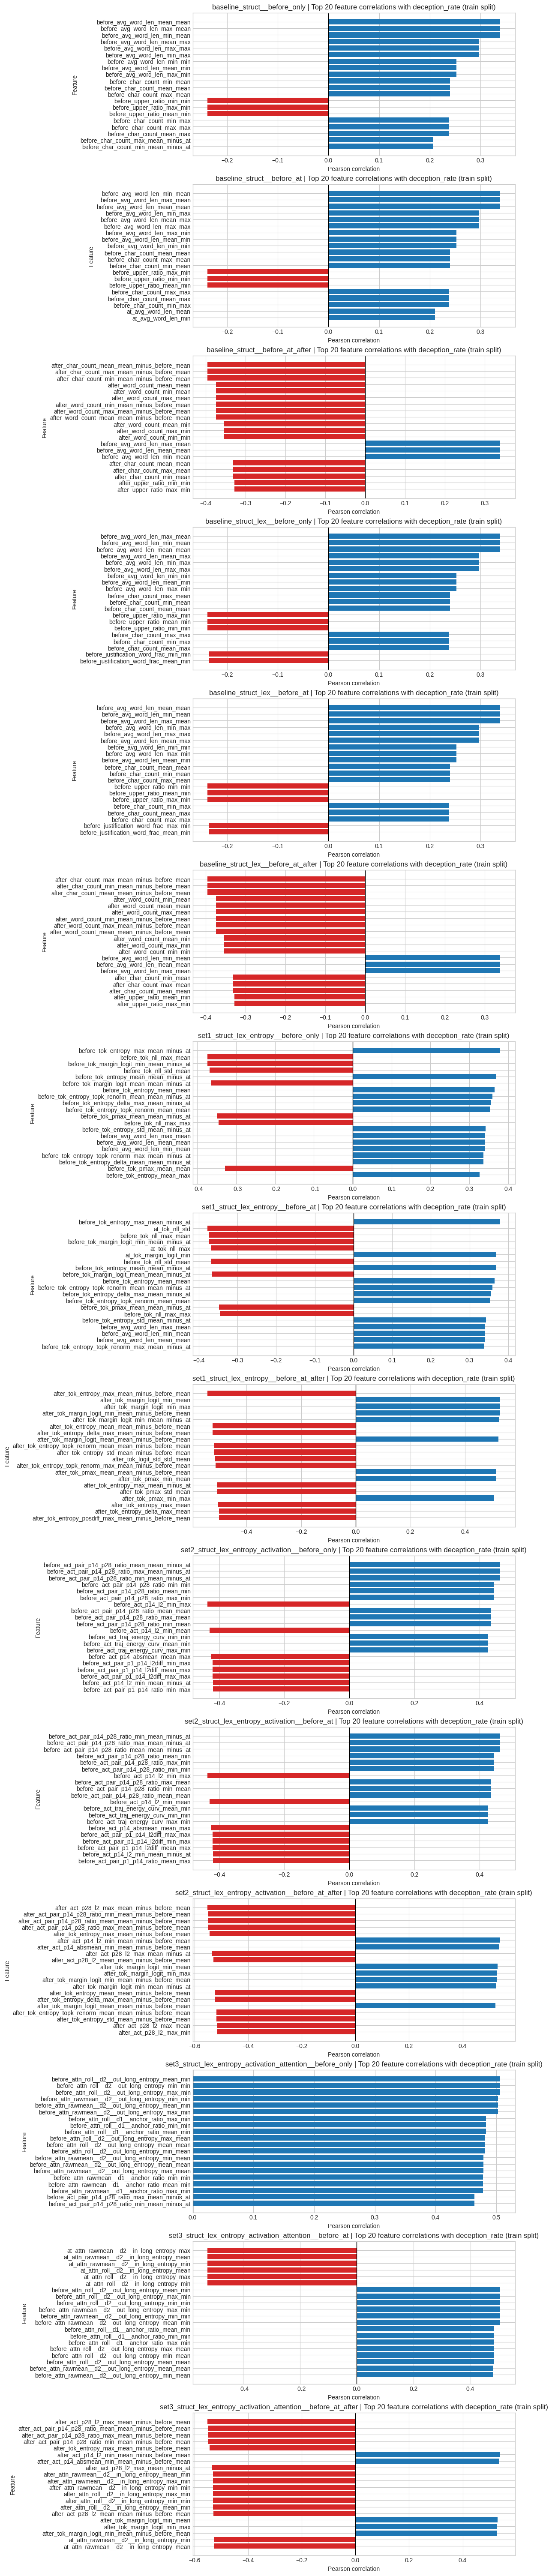

Saved top-correlation tables to: /playpen-ssd/smerrill/deception2/BS/Results/SentencePipeline/v1/ood_modeling


In [6]:
# -------------------------
# Top correlation plots (train split only)
# -------------------------
correlation_tables = {}

y_train_series = train_df['deception_rate']

fig, axes = plt.subplots(len(feature_sets), 1, figsize=(12, 4 * len(feature_sets)), constrained_layout=True)
if len(feature_sets) == 1:
    axes = [axes]

for ax, (set_name, cols) in zip(axes, feature_sets.items()):
    xtr = sanitize_numeric(train_df, cols)
    top_corr = top_correlations(xtr, y_train_series, k=TOP_CORR_K)
    correlation_tables[set_name] = top_corr

    if top_corr.empty:
        ax.set_title(f'{set_name}: no valid correlations')
        ax.axis('off')
        continue

    colors = np.where(top_corr['corr'] >= 0, '#1f77b4', '#d62728')
    ax.barh(top_corr['feature'][::-1], top_corr['corr'][::-1], color=colors[::-1])
    ax.axvline(0.0, color='black', linewidth=1)
    ax.set_title(f'{set_name} | Top {len(top_corr)} feature correlations with deception_rate (train split)')
    ax.set_xlabel('Pearson correlation')
    ax.set_ylabel('Feature')

plt.show()

for set_name, tbl in correlation_tables.items():
    out = RESULTS_DIR / f'{TRAIN_ENV}_to_{OOD_ENV}__{set_name}__top_correlations.csv'
    tbl.to_csv(out, index=False)

print(f'Saved top-correlation tables to: {RESULTS_DIR}')


In [7]:
# -------------------------
# Fit XGBoost per feature set (val selection + OOD evaluation)
# -------------------------
XGB_DEVICE = detect_xgb_device()
print(f'Using XGBoost device: {XGB_DEVICE}')

results_rows = []
models = {}
importances = {}

for set_name, cols in feature_sets.items():
    print(f'\n=== Training {set_name} ({len(cols)} features) ===')

    x_train = sanitize_numeric(train_df, cols).astype(np.float32)
    x_val = sanitize_numeric(val_df, cols).astype(np.float32)
    x_ood = sanitize_numeric(ood_df, cols).astype(np.float32)

    y_train = train_df['deception_rate'].to_numpy(dtype=np.float32)
    y_val = val_df['deception_rate'].to_numpy(dtype=np.float32)
    y_ood = ood_df['deception_rate'].to_numpy(dtype=np.float32)

    best = run_xgb_model_search(
        x_train,
        y_train,
        x_val,
        y_val,
        seed=SEED,
        n_jobs=N_JOBS,
        early_stopping_rounds=EARLY_STOPPING_ROUNDS,
        device=XGB_DEVICE,
    )

    best_model = best['model']
    val_pred = best['val_pred']
    ood_pred = best_model.predict(x_ood)

    val_metrics = regression_metrics(y_val, val_pred)
    ood_metrics = regression_metrics(y_ood, ood_pred)

    row = {
        'train_env': TRAIN_ENV,
        'ood_env': OOD_ENV,
        'feature_set': set_name,
        'n_features': len(cols),
        'device': XGB_DEVICE,
        'best_iteration': int(best['best_iteration']) if best['best_iteration'] is not None else np.nan,
        'objective': best['config']['objective'],
        'learning_rate': best['config']['learning_rate'],
        'max_depth': best['config']['max_depth'],
        'min_child_weight': best['config']['min_child_weight'],
        'subsample': best['config']['subsample'],
        'colsample_bytree': best['config']['colsample_bytree'],
        'reg_lambda': best['config']['reg_lambda'],
        'reg_alpha': best['config']['reg_alpha'],
        'val_rmse': val_metrics['rmse'],
        'val_mae': val_metrics['mae'],
        'val_r2': val_metrics['r2'],
        'val_pearson': val_metrics['pearson'],
        'ood_rmse': ood_metrics['rmse'],
        'ood_mae': ood_metrics['mae'],
        'ood_r2': ood_metrics['r2'],
        'ood_pearson': ood_metrics['pearson'],
    }
    results_rows.append(row)

    models[set_name] = best_model
    importances[set_name] = extract_importance_df(best_model, cols)

results_df = pd.DataFrame(results_rows).sort_values('ood_rmse').reset_index(drop=True)
results_df


Using XGBoost device: cuda

=== Training baseline_struct__before_only (160 features) ===


/playpen-ssd/smerrill/conda_envs/deception/lib/python3.11/site-packages/xgboost/core.py:751: UserWarning: [11:31:45] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)



=== Training baseline_struct__before_at (192 features) ===

=== Training baseline_struct__before_at_after (384 features) ===

=== Training baseline_struct_lex__before_only (300 features) ===

=== Training baseline_struct_lex__before_at (360 features) ===

=== Training baseline_struct_lex__before_at_after (720 features) ===

=== Training set1_struct_lex_entropy__before_only (460 features) ===

=== Training set1_struct_lex_entropy__before_at (552 features) ===

=== Training set1_struct_lex_entropy__before_at_after (1104 features) ===

=== Training set2_struct_lex_entropy_activation__before_only (860 features) ===

=== Training set2_struct_lex_entropy_activation__before_at (1032 features) ===

=== Training set2_struct_lex_entropy_activation__before_at_after (2064 features) ===

=== Training set3_struct_lex_entropy_activation_attention__before_only (1060 features) ===

=== Training set3_struct_lex_entropy_activation_attention__before_at (1272 features) ===

=== Training set3_struct_lex_en

,train_env,ood_env,feature_set,n_features,device,best_iteration,objective,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,reg_lambda,reg_alpha,val_rmse,val_mae,val_r2,val_pearson,ood_rmse,ood_mae,ood_r2,ood_pearson
0,BS,Gridworld,set3_struct_lex_entropy_activation_attention__...,2544,cuda,710,reg:pseudohubererror,0.02,5,12,0.80,0.5,8.0,1.0,0.179884,0.136972,0.543574,0.737775,0.292752,0.245699,0.327525,0.693564
1,BS,Gridworld,set2_struct_lex_entropy_activation__before_at_...,2064,cuda,684,reg:pseudohubererror,0.02,5,12,0.80,0.5,8.0,1.0,0.182931,0.140014,0.527981,0.727123,0.300435,0.252778,0.291765,0.672505
2,BS,Gridworld,set3_struct_lex_entropy_activation_attention__...,1272,cuda,696,reg:squarederror,0.02,5,12,0.80,0.5,8.0,1.0,0.200499,0.155893,0.432960,0.658524,0.308108,0.260618,0.255130,0.656676
3,BS,Gridworld,set3_struct_lex_entropy_activation_attention__...,1060,cuda,524,reg:squarederror,0.03,6,8,0.85,0.6,5.0,0.5,0.201042,0.156393,0.429887,0.656158,0.309331,0.262143,0.249202,0.651766
4,BS,Gridworld,set2_struct_lex_entropy_activation__before_only,860,cuda,542,reg:pseudohubererror,0.02,5,12,0.80,0.5,8.0,1.0,0.204779,0.159695,0.408496,0.639418,0.315208,0.271518,0.220404,0.609922
5,BS,Gridworld,set2_struct_lex_entropy_activation__before_at,1032,cuda,680,reg:pseudohubererror,0.02,5,12,0.80,0.5,8.0,1.0,0.204059,0.158919,0.412647,0.642640,0.317529,0.274277,0.208879,0.603945
6,BS,Gridworld,set1_struct_lex_entropy__before_at_after,1104,cuda,277,reg:squarederror,0.03,6,8,0.85,0.6,5.0,0.5,0.183908,0.141284,0.522925,0.723864,0.318947,0.270022,0.201801,0.643757
7,BS,Gridworld,baseline_struct_lex__before_at_after,720,cuda,268,reg:squarederror,0.03,6,8,0.85,0.6,5.0,0.5,0.186417,0.143633,0.509816,0.714786,0.320312,0.271060,0.194952,0.624333
8,BS,Gridworld,baseline_struct__before_at_after,384,cuda,366,reg:pseudohubererror,0.02,5,12,0.80,0.5,8.0,1.0,0.186891,0.143603,0.507320,0.712865,0.328031,0.277125,0.155683,0.614782
9,BS,Gridworld,set1_struct_lex_entropy__before_at,552,cuda,945,reg:squarederror,0.02,5,12,0.80,0.5,8.0,1.0,0.206409,0.161366,0.399039,0.632114,0.338253,0.293480,0.102243,0.547555


In [23]:
results_df

,train_env,ood_env,feature_set,n_features,device,best_iteration,objective,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,reg_lambda,reg_alpha,val_rmse,val_mae,val_r2,val_pearson,ood_rmse,ood_mae,ood_r2,ood_pearson
0,BS,Gridworld,set3_struct_lex_entropy_activation_attention__before_at_after,2544,cuda,710,reg:pseudohubererror,0.02,5,12,0.80,0.5,8.0,1.0,0.179884,0.136972,0.543574,0.737775,0.292752,0.245699,0.327525,0.693564
1,BS,Gridworld,set2_struct_lex_entropy_activation__before_at_after,2064,cuda,684,reg:pseudohubererror,0.02,5,12,0.80,0.5,8.0,1.0,0.182931,0.140014,0.527981,0.727123,0.300435,0.252778,0.291765,0.672505
2,BS,Gridworld,set3_struct_lex_entropy_activation_attention__before_at,1272,cuda,696,reg:squarederror,0.02,5,12,0.80,0.5,8.0,1.0,0.200499,0.155893,0.432960,0.658524,0.308108,0.260618,0.255130,0.656676
3,BS,Gridworld,set3_struct_lex_entropy_activation_attention__before_only,1060,cuda,524,reg:squarederror,0.03,6,8,0.85,0.6,5.0,0.5,0.201042,0.156393,0.429887,0.656158,0.309331,0.262143,0.249202,0.651766
4,BS,Gridworld,set2_struct_lex_entropy_activation__before_only,860,cuda,542,reg:pseudohubererror,0.02,5,12,0.80,0.5,8.0,1.0,0.204779,0.159695,0.408496,0.639418,0.315208,0.271518,0.220404,0.609922
5,BS,Gridworld,set2_struct_lex_entropy_activation__before_at,1032,cuda,680,reg:pseudohubererror,0.02,5,12,0.80,0.5,8.0,1.0,0.204059,0.158919,0.412647,0.642640,0.317529,0.274277,0.208879,0.603945
6,BS,Gridworld,set1_struct_lex_entropy__before_at_after,1104,cuda,277,reg:squarederror,0.03,6,8,0.85,0.6,5.0,0.5,0.183908,0.141284,0.522925,0.723864,0.318947,0.270022,0.201801,0.643757
7,BS,Gridworld,baseline_struct_lex__before_at_after,720,cuda,268,reg:squarederror,0.03,6,8,0.85,0.6,5.0,0.5,0.186417,0.143633,0.509816,0.714786,0.320312,0.271060,0.194952,0.624333
8,BS,Gridworld,baseline_struct__before_at_after,384,cuda,366,reg:pseudohubererror,0.02,5,12,0.80,0.5,8.0,1.0,0.186891,0.143603,0.507320,0.712865,0.328031,0.277125,0.155683,0.614782
9,BS,Gridworld,set1_struct_lex_entropy__before_at,552,cuda,945,reg:squarederror,0.02,5,12,0.80,0.5,8.0,1.0,0.206409,0.161366,0.399039,0.632114,0.338253,0.293480,0.102243,0.547555


In [27]:
pd.set_option('display.max_colwidth', None)
results_df[['feature_set', 'feature_set', 'train_env', 'ood_env', 'val_r2', 'ood_r2', 'val_pearson', 'ood_pearson', 'feature_set']]

,feature_set,feature_set,train_env,ood_env,val_r2,ood_r2,val_pearson,ood_pearson,feature_set
0,set3_struct_lex_entropy_activation_attention__before_at_after,set3_struct_lex_entropy_activation_attention__before_at_after,BS,Gridworld,0.543574,0.327525,0.737775,0.693564,set3_struct_lex_entropy_activation_attention__before_at_after
1,set2_struct_lex_entropy_activation__before_at_after,set2_struct_lex_entropy_activation__before_at_after,BS,Gridworld,0.527981,0.291765,0.727123,0.672505,set2_struct_lex_entropy_activation__before_at_after
2,set3_struct_lex_entropy_activation_attention__before_at,set3_struct_lex_entropy_activation_attention__before_at,BS,Gridworld,0.432960,0.255130,0.658524,0.656676,set3_struct_lex_entropy_activation_attention__before_at
3,set3_struct_lex_entropy_activation_attention__before_only,set3_struct_lex_entropy_activation_attention__before_only,BS,Gridworld,0.429887,0.249202,0.656158,0.651766,set3_struct_lex_entropy_activation_attention__before_only
4,set2_struct_lex_entropy_activation__before_only,set2_struct_lex_entropy_activation__before_only,BS,Gridworld,0.408496,0.220404,0.639418,0.609922,set2_struct_lex_entropy_activation__before_only
5,set2_struct_lex_entropy_activation__before_at,set2_struct_lex_entropy_activation__before_at,BS,Gridworld,0.412647,0.208879,0.642640,0.603945,set2_struct_lex_entropy_activation__before_at
6,set1_struct_lex_entropy__before_at_after,set1_struct_lex_entropy__before_at_after,BS,Gridworld,0.522925,0.201801,0.723864,0.643757,set1_struct_lex_entropy__before_at_after
7,baseline_struct_lex__before_at_after,baseline_struct_lex__before_at_after,BS,Gridworld,0.509816,0.194952,0.714786,0.624333,baseline_struct_lex__before_at_after
8,baseline_struct__before_at_after,baseline_struct__before_at_after,BS,Gridworld,0.507320,0.155683,0.712865,0.614782,baseline_struct__before_at_after
9,set1_struct_lex_entropy__before_at,set1_struct_lex_entropy__before_at,BS,Gridworld,0.399039,0.102243,0.632114,0.547555,set1_struct_lex_entropy__before_at


In [8]:
# Baseline deltas (negative RMSE/MAE delta means improvement)
baseline_row = results_df[results_df['feature_set'] == 'baseline_struct']
if len(baseline_row) == 1:
    b = baseline_row.iloc[0]
    results_with_delta = results_df.copy()
    results_with_delta['val_rmse_delta_vs_baseline'] = results_with_delta['val_rmse'] - float(b['val_rmse'])
    results_with_delta['ood_rmse_delta_vs_baseline'] = results_with_delta['ood_rmse'] - float(b['ood_rmse'])
    results_with_delta['val_pearson_delta_vs_baseline'] = results_with_delta['val_pearson'] - float(b['val_pearson'])
    results_with_delta['ood_pearson_delta_vs_baseline'] = results_with_delta['ood_pearson'] - float(b['ood_pearson'])
    display(results_with_delta)
else:
    print('baseline_struct row not found uniquely; skipping delta table')


baseline_struct row not found uniquely; skipping delta table


In [9]:
# Save metrics + importances
run_tag = f'{TRAIN_ENV}_to_{OOD_ENV}__{FEATURE_SOURCE_MODE}'
if FEATURE_SOURCE_MODE == 'temporal_reduced' and ENABLE_TEMPORAL_SCOPE_SWEEP:
    run_tag += '__scope_sweep'
metrics_out = RESULTS_DIR / f'{run_tag}__xgb_metrics.csv'
results_df.to_csv(metrics_out, index=False)

for set_name, imp_df in importances.items():
    imp_out = RESULTS_DIR / f'{run_tag}__{set_name}__importance_gain.csv'
    imp_df.to_csv(imp_out, index=False)

print(f'Saved metrics to: {metrics_out}')
print(f'Saved feature importances to: {RESULTS_DIR}')


Saved metrics to: /playpen-ssd/smerrill/deception2/BS/Results/SentencePipeline/v1/ood_modeling/BS_to_Gridworld__temporal_reduced__scope_sweep__xgb_metrics.csv
Saved feature importances to: /playpen-ssd/smerrill/deception2/BS/Results/SentencePipeline/v1/ood_modeling


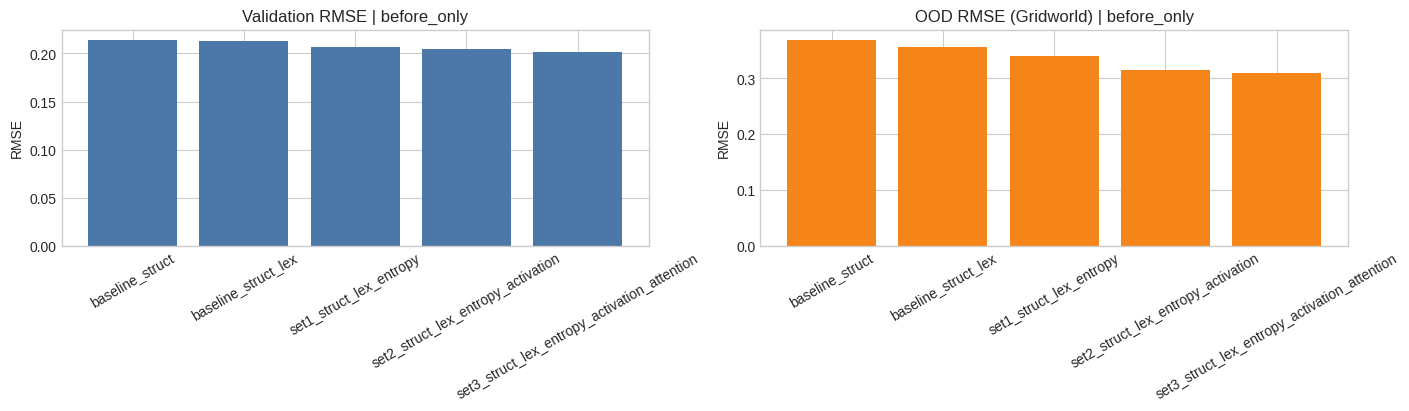

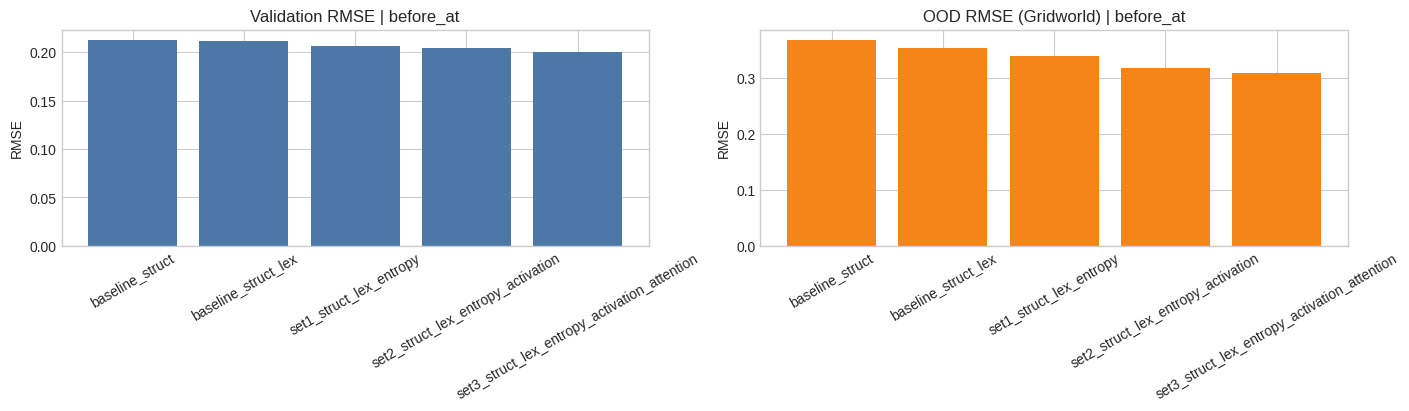

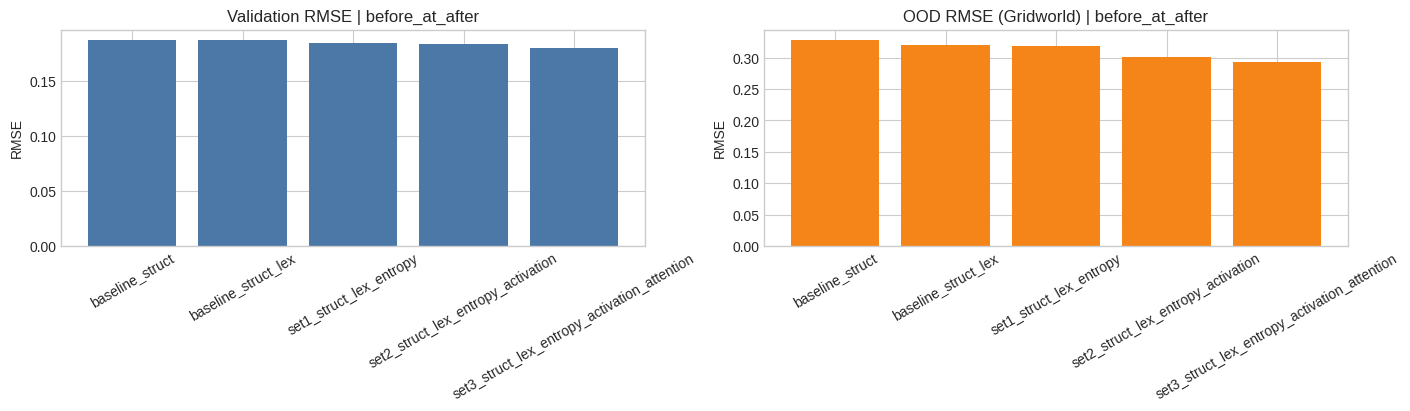

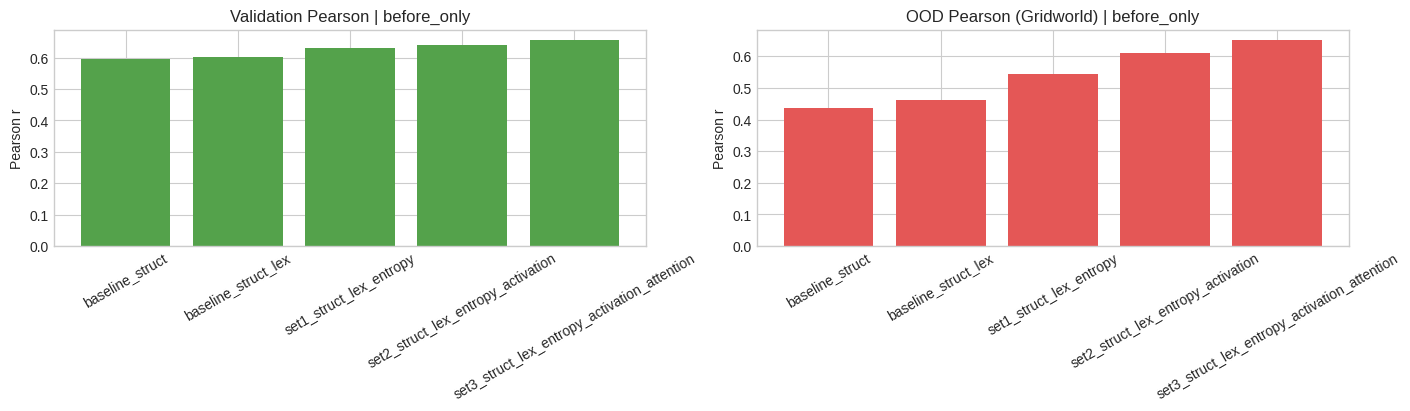

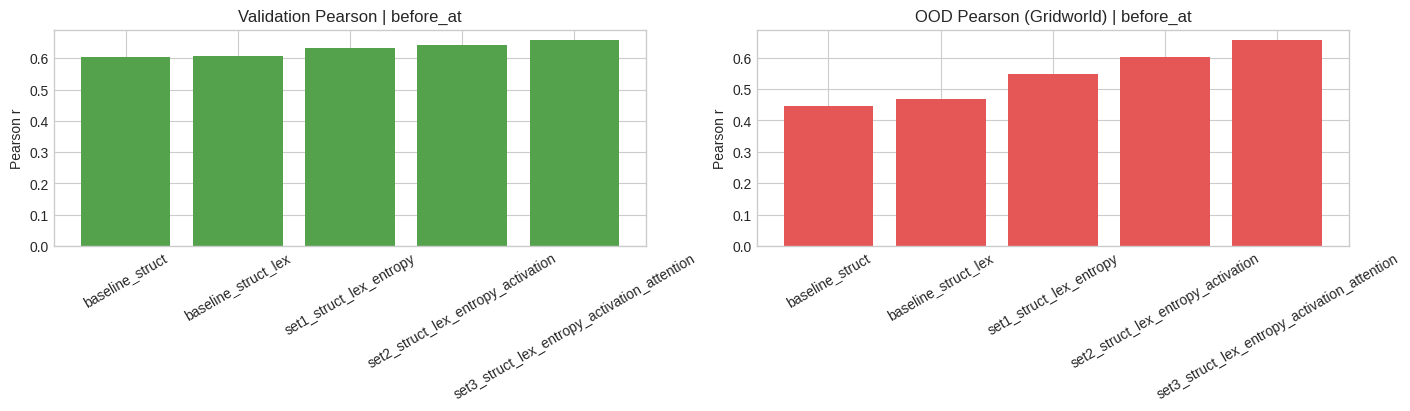

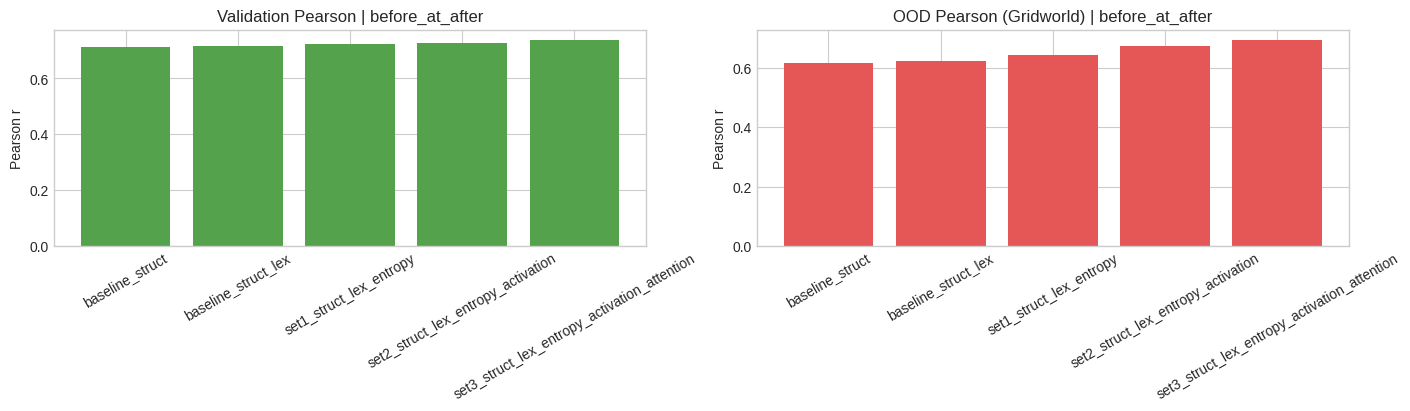

In [10]:
# -------------------------
# Metric comparison plots (temporal-scope separated)
# -------------------------
plot_df = results_df.copy()

if 'base_feature_set' not in plot_df.columns or 'temporal_scope' not in plot_df.columns:
    split = plot_df['feature_set'].astype(str).str.rsplit('__', n=1, expand=True)
    if split.shape[1] == 2:
        plot_df['base_feature_set'] = split[0]
        plot_df['temporal_scope'] = split[1]
    else:
        plot_df['base_feature_set'] = plot_df['feature_set']
        plot_df['temporal_scope'] = 'original'

scope_order_pref = ['before_only', 'before_at', 'before_at_after', 'original']
scope_order = [s for s in scope_order_pref if s in set(plot_df['temporal_scope'])]
if len(scope_order) == 0:
    scope_order = sorted(plot_df['temporal_scope'].dropna().unique().tolist())

for scope in scope_order:
    sub = plot_df[plot_df['temporal_scope'] == scope].copy()
    if sub.empty:
        continue

    ordered_sets = [s for s in feature_sets.keys() if s.endswith(f'__{scope}')]
    base_order = [s.rsplit('__', 1)[0] for s in ordered_sets]
    if len(base_order) == 0:
        base_order = sub['base_feature_set'].tolist()

    sub = sub.set_index('base_feature_set').reindex(base_order).reset_index()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)
    axes[0].bar(sub['base_feature_set'], sub['val_rmse'], color='#4c78a8')
    axes[0].set_title(f'Validation RMSE | {scope}')
    axes[0].set_ylabel('RMSE')
    axes[0].tick_params(axis='x', rotation=30)

    axes[1].bar(sub['base_feature_set'], sub['ood_rmse'], color='#f58518')
    axes[1].set_title(f'OOD RMSE ({OOD_ENV}) | {scope}')
    axes[1].set_ylabel('RMSE')
    axes[1].tick_params(axis='x', rotation=30)
    plt.show()

for scope in scope_order:
    sub = plot_df[plot_df['temporal_scope'] == scope].copy()
    if sub.empty:
        continue

    ordered_sets = [s for s in feature_sets.keys() if s.endswith(f'__{scope}')]
    base_order = [s.rsplit('__', 1)[0] for s in ordered_sets]
    if len(base_order) == 0:
        base_order = sub['base_feature_set'].tolist()

    sub = sub.set_index('base_feature_set').reindex(base_order).reset_index()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)
    axes[0].bar(sub['base_feature_set'], sub['val_pearson'], color='#54a24b')
    axes[0].set_title(f'Validation Pearson | {scope}')
    axes[0].set_ylabel('Pearson r')
    axes[0].tick_params(axis='x', rotation=30)

    axes[1].bar(sub['base_feature_set'], sub['ood_pearson'], color='#e45756')
    axes[1].set_title(f'OOD Pearson ({OOD_ENV}) | {scope}')
    axes[1].set_ylabel('Pearson r')
    axes[1].tick_params(axis='x', rotation=30)
    plt.show()


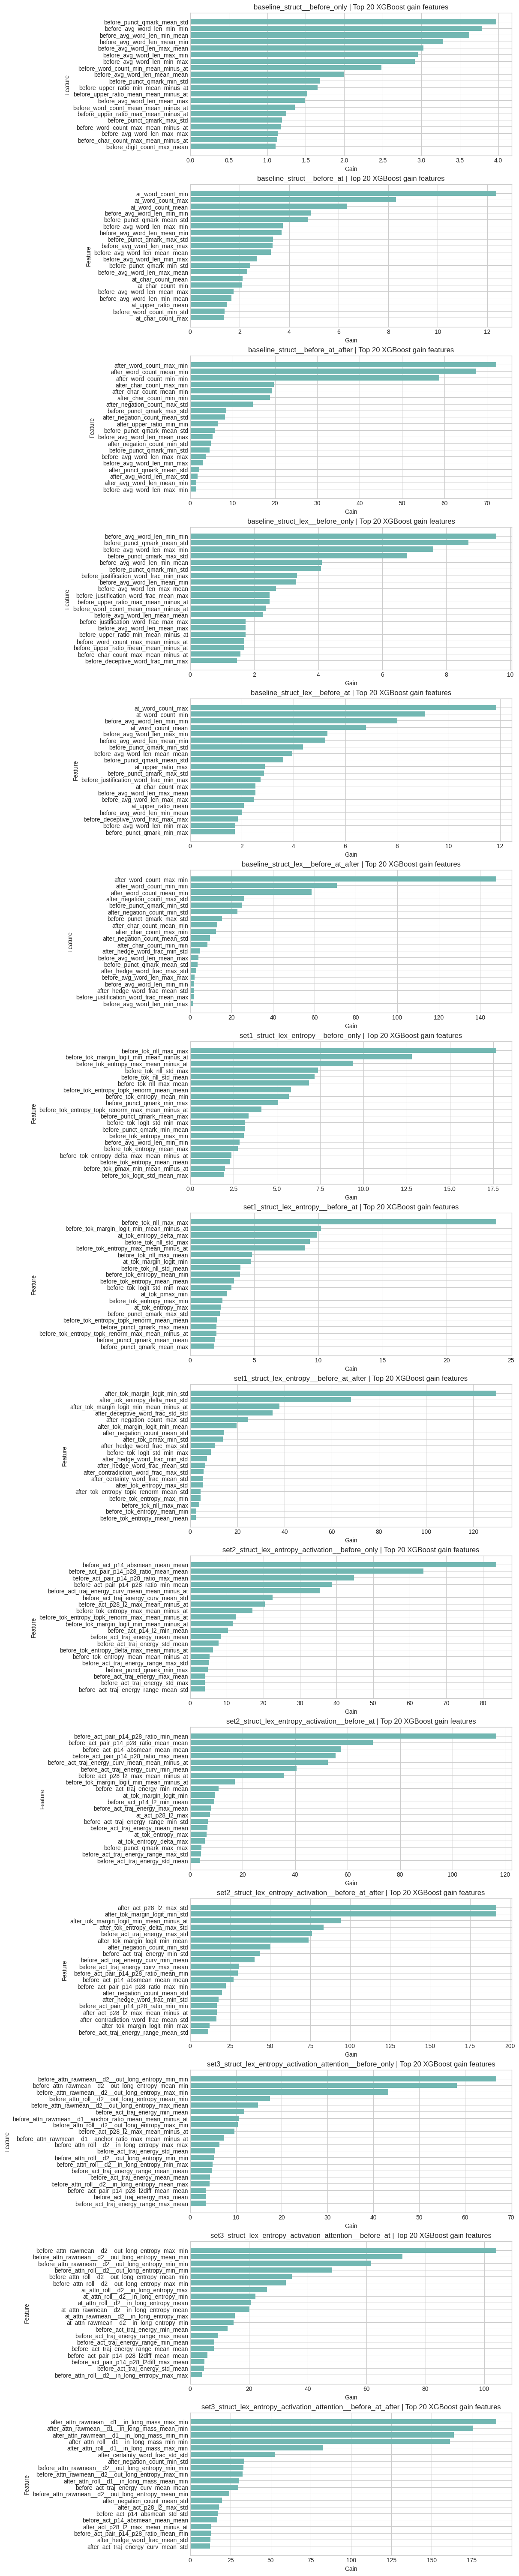

In [11]:
# -------------------------
# Feature-importance plots (gain)
# -------------------------
TOP_IMPORTANCE_K = 20

fig, axes = plt.subplots(len(feature_sets), 1, figsize=(12, 4 * len(feature_sets)), constrained_layout=True)
if len(feature_sets) == 1:
    axes = [axes]

for ax, set_name in zip(axes, feature_sets.keys()):
    imp = importances[set_name].head(TOP_IMPORTANCE_K).copy()
    if imp.empty or float(imp['gain'].sum()) == 0.0:
        ax.set_title(f'{set_name}: no non-zero gain features')
        ax.axis('off')
        continue

    imp = imp.sort_values('gain', ascending=True)
    ax.barh(imp['feature'], imp['gain'], color='#72b7b2')
    ax.set_title(f'{set_name} | Top {len(imp)} XGBoost gain features')
    ax.set_xlabel('Gain')
    ax.set_ylabel('Feature')

plt.show()


## Thresholded Classification (XGBoost)

This section treats `deception_rate > threshold` as a binary target for thresholds:
- `0.3`
- `0.4`
- `0.5`
- `0.6`

It evaluates all feature sets (original + temporal) with XGBoost classification on:
- in-domain validation split
- OOD environment test split


In [12]:
# -------------------------
# Classification helpers
# -------------------------
CLASS_THRESHOLDS = [0.3, 0.4, 0.5, 0.6]
CLASS_PROB_CUTOFF = 0.5


def binary_metrics(y_true: np.ndarray, y_prob: np.ndarray, *, cutoff: float = 0.5) -> dict:
    y_true = np.asarray(y_true, dtype=int)
    y_prob = np.asarray(y_prob, dtype=float)
    y_pred = (y_prob >= cutoff).astype(int)

    out = {
        'f1': float(f1_score(y_true, y_pred, zero_division=0)),
        'precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'recall': float(recall_score(y_true, y_pred, zero_division=0)),
        'accuracy': float(accuracy_score(y_true, y_pred)),
    }

    if len(np.unique(y_true)) == 2:
        try:
            out['roc_auc'] = float(roc_auc_score(y_true, y_prob))
        except Exception:
            out['roc_auc'] = np.nan
    else:
        out['roc_auc'] = np.nan

    out['cm'] = confusion_matrix(y_true, y_pred, labels=[0, 1])
    return out


def run_xgb_classifier_search(
    x_train: pd.DataFrame,
    y_train: np.ndarray,
    x_val: pd.DataFrame,
    y_val: np.ndarray,
    *,
    seed: int,
    n_jobs: int,
    early_stopping_rounds: int,
    device: str,
):
    pos = int(np.sum(y_train == 1))
    neg = int(np.sum(y_train == 0))
    if pos == 0 or neg == 0:
        return None

    # Class-imbalance weighting requested: exact neg/pos ratio.
    spw = float(neg) / float(pos)

    param_grid = [
        {
            'learning_rate': 0.03,
            'max_depth': 6,
            'min_child_weight': 8,
            'subsample': 0.85,
            'colsample_bytree': 0.60,
            'reg_lambda': 5.0,
            'reg_alpha': 0.5,
            'scale_pos_weight': spw,
        },
        {
            'learning_rate': 0.02,
            'max_depth': 5,
            'min_child_weight': 12,
            'subsample': 0.80,
            'colsample_bytree': 0.50,
            'reg_lambda': 8.0,
            'reg_alpha': 1.0,
            'scale_pos_weight': spw,
        },
        {
            'learning_rate': 0.02,
            'max_depth': 4,
            'min_child_weight': 10,
            'subsample': 0.90,
            'colsample_bytree': 0.70,
            'reg_lambda': 4.0,
            'reg_alpha': 0.2,
            'scale_pos_weight': spw,
        },
    ]

    best = None
    best_val_f1 = -1.0

    for cfg in param_grid:
        model = xgb.XGBClassifier(
            n_estimators=3500,
            objective='binary:logistic',
            random_state=seed,
            tree_method='hist',
            device=device,
            eval_metric='logloss',
            early_stopping_rounds=early_stopping_rounds,
            n_jobs=n_jobs,
            **cfg,
        )
        model.fit(x_train, y_train, eval_set=[(x_val, y_val)], verbose=False)

        val_prob = model.predict_proba(x_val)[:, 1]
        val_f1 = float(f1_score(y_val, (val_prob >= CLASS_PROB_CUTOFF).astype(int), zero_division=0))

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best = {
                'model': model,
                'config': cfg,
                'val_prob': val_prob,
                'val_f1': val_f1,
                'best_iteration': getattr(model, 'best_iteration', None),
            }

    return best


def feature_set_has_activation(cols: list[str]) -> bool:
    return any(('act_' in c) for c in cols)


In [13]:
# -------------------------
# Fit thresholded classifiers for all feature sets
# -------------------------
classification_rows = []
classification_models = {}
classification_confmats = {}

XGB_DEVICE_CLS = detect_xgb_device()
print(f'Using XGBoost device for classification: {XGB_DEVICE_CLS}')

for thr in CLASS_THRESHOLDS:
    print(f'\n===== Threshold > {thr:.1f} =====')

    y_train_bin = (train_df['deception_rate'].to_numpy(dtype=float) > thr).astype(int)
    y_val_bin = (val_df['deception_rate'].to_numpy(dtype=float) > thr).astype(int)
    y_ood_bin = (ood_df['deception_rate'].to_numpy(dtype=float) > thr).astype(int)

    train_pos_rate = float(y_train_bin.mean())
    val_pos_rate = float(y_val_bin.mean())
    ood_pos_rate = float(y_ood_bin.mean())
    print(f'Pos rate train/val/ood: {train_pos_rate:.4f} / {val_pos_rate:.4f} / {ood_pos_rate:.4f}')

    for set_name, cols in feature_sets.items():
        print(f'  - {set_name} ({len(cols)} features)')

        x_train = sanitize_numeric(train_df, cols).astype(np.float32)
        x_val = sanitize_numeric(val_df, cols).astype(np.float32)
        x_ood = sanitize_numeric(ood_df, cols).astype(np.float32)

        has_act = feature_set_has_activation(cols)

        # Degenerate case: train split has only one class.
        if len(np.unique(y_train_bin)) < 2:
            const_prob = float(np.mean(y_train_bin))
            val_prob = np.full(len(y_val_bin), const_prob, dtype=float)
            ood_prob = np.full(len(y_ood_bin), const_prob, dtype=float)

            val_m = binary_metrics(y_val_bin, val_prob, cutoff=CLASS_PROB_CUTOFF)
            ood_m = binary_metrics(y_ood_bin, ood_prob, cutoff=CLASS_PROB_CUTOFF)

            row = {
                'threshold': thr,
                'feature_set': set_name,
                'has_activation': has_act,
                'n_features': len(cols),
                'device': XGB_DEVICE_CLS,
                'best_iteration': np.nan,
                'objective': 'constant_predictor',
                'learning_rate': np.nan,
                'max_depth': np.nan,
                'min_child_weight': np.nan,
                'subsample': np.nan,
                'colsample_bytree': np.nan,
                'reg_lambda': np.nan,
                'reg_alpha': np.nan,
                'scale_pos_weight': np.nan,
                'val_f1': val_m['f1'],
                'val_precision': val_m['precision'],
                'val_recall': val_m['recall'],
                'val_accuracy': val_m['accuracy'],
                'val_roc_auc': val_m['roc_auc'],
                'ood_f1': ood_m['f1'],
                'ood_precision': ood_m['precision'],
                'ood_recall': ood_m['recall'],
                'ood_accuracy': ood_m['accuracy'],
                'ood_roc_auc': ood_m['roc_auc'],
            }
            classification_rows.append(row)
            classification_confmats[(thr, set_name, 'val')] = val_m['cm']
            classification_confmats[(thr, set_name, 'ood')] = ood_m['cm']
            continue

        best = run_xgb_classifier_search(
            x_train,
            y_train_bin,
            x_val,
            y_val_bin,
            seed=SEED,
            n_jobs=N_JOBS,
            early_stopping_rounds=EARLY_STOPPING_ROUNDS,
            device=XGB_DEVICE_CLS,
        )

        if best is None:
            # Safety fallback.
            const_prob = float(np.mean(y_train_bin))
            val_prob = np.full(len(y_val_bin), const_prob, dtype=float)
            ood_prob = np.full(len(y_ood_bin), const_prob, dtype=float)
            cfg = {'learning_rate': np.nan, 'max_depth': np.nan, 'min_child_weight': np.nan, 'subsample': np.nan, 'colsample_bytree': np.nan, 'reg_lambda': np.nan, 'reg_alpha': np.nan, 'scale_pos_weight': np.nan}
            best_iter = np.nan
            objective = 'fallback_constant'
        else:
            model = best['model']
            cfg = best['config']
            best_iter = int(best['best_iteration']) if best['best_iteration'] is not None else np.nan
            objective = 'binary:logistic'
            val_prob = best['val_prob']
            ood_prob = model.predict_proba(x_ood)[:, 1]
            classification_models[(thr, set_name)] = model

        val_m = binary_metrics(y_val_bin, val_prob, cutoff=CLASS_PROB_CUTOFF)
        ood_m = binary_metrics(y_ood_bin, ood_prob, cutoff=CLASS_PROB_CUTOFF)

        row = {
            'threshold': thr,
            'feature_set': set_name,
            'has_activation': has_act,
            'n_features': len(cols),
            'device': XGB_DEVICE_CLS,
            'best_iteration': best_iter,
            'objective': objective,
            'learning_rate': cfg['learning_rate'],
            'max_depth': cfg['max_depth'],
            'min_child_weight': cfg['min_child_weight'],
            'subsample': cfg['subsample'],
            'colsample_bytree': cfg['colsample_bytree'],
            'reg_lambda': cfg['reg_lambda'],
            'reg_alpha': cfg['reg_alpha'],
            'scale_pos_weight': cfg['scale_pos_weight'],
            'val_f1': val_m['f1'],
            'val_precision': val_m['precision'],
            'val_recall': val_m['recall'],
            'val_accuracy': val_m['accuracy'],
            'val_roc_auc': val_m['roc_auc'],
            'ood_f1': ood_m['f1'],
            'ood_precision': ood_m['precision'],
            'ood_recall': ood_m['recall'],
            'ood_accuracy': ood_m['accuracy'],
            'ood_roc_auc': ood_m['roc_auc'],
        }
        classification_rows.append(row)
        classification_confmats[(thr, set_name, 'val')] = val_m['cm']
        classification_confmats[(thr, set_name, 'ood')] = ood_m['cm']

classification_df = pd.DataFrame(classification_rows).sort_values(['threshold', 'ood_f1'], ascending=[True, False]).reset_index(drop=True)
classification_df


Using XGBoost device for classification: cuda

===== Threshold > 0.3 =====
Pos rate train/val/ood: 0.8427 / 0.8457 / 0.5583
  - baseline_struct__before_only (160 features)
  - baseline_struct__before_at (192 features)
  - baseline_struct__before_at_after (384 features)
  - baseline_struct_lex__before_only (300 features)
  - baseline_struct_lex__before_at (360 features)
  - baseline_struct_lex__before_at_after (720 features)
  - set1_struct_lex_entropy__before_only (460 features)
  - set1_struct_lex_entropy__before_at (552 features)
  - set1_struct_lex_entropy__before_at_after (1104 features)
  - set2_struct_lex_entropy_activation__before_only (860 features)
  - set2_struct_lex_entropy_activation__before_at (1032 features)
  - set2_struct_lex_entropy_activation__before_at_after (2064 features)
  - set3_struct_lex_entropy_activation_attention__before_only (1060 features)
  - set3_struct_lex_entropy_activation_attention__before_at (1272 features)
  - set3_struct_lex_entropy_activation_att

,threshold,feature_set,has_activation,n_features,device,best_iteration,objective,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,reg_lambda,reg_alpha,scale_pos_weight,val_f1,val_precision,val_recall,val_accuracy,val_roc_auc,ood_f1,ood_precision,ood_recall,ood_accuracy,ood_roc_auc
0,0.3,set3_struct_lex_entropy_activation_attention__...,True,1060,cuda,3495,binary:logistic,0.03,6,8,0.85,0.6,5.0,0.5,0.186617,0.882787,0.882504,0.883070,0.801672,0.713103,0.746583,0.603282,0.979170,0.628889,0.757050
1,0.3,set2_struct_lex_entropy_activation__before_only,True,860,cuda,3086,binary:logistic,0.03,6,8,0.85,0.6,5.0,0.5,0.186617,0.877713,0.880719,0.874727,0.793856,0.701109,0.743062,0.597783,0.981627,0.621001,0.708970
2,0.3,set3_struct_lex_entropy_activation_attention__...,True,1272,cuda,3464,binary:logistic,0.03,6,8,0.85,0.6,5.0,0.5,0.186617,0.886890,0.881659,0.892183,0.807534,0.717655,0.743010,0.598808,0.978695,0.622030,0.752651
3,0.3,set2_struct_lex_entropy_activation__before_at,True,1032,cuda,3383,binary:logistic,0.03,6,8,0.85,0.6,5.0,0.5,0.186617,0.883075,0.880148,0.886022,0.801563,0.703904,0.742510,0.596821,0.982297,0.619645,0.711861
4,0.3,set1_struct_lex_entropy__before_only,False,460,cuda,3496,binary:logistic,0.03,6,8,0.85,0.6,5.0,0.5,0.186617,0.875573,0.880977,0.870235,0.790816,0.688126,0.740423,0.594641,0.980901,0.616029,0.670043
5,0.3,baseline_struct_lex__before_only,False,300,cuda,3499,binary:logistic,0.03,6,8,0.85,0.6,5.0,0.5,0.186617,0.850688,0.881923,0.821589,0.756079,0.665179,0.739977,0.607770,0.945690,0.628952,0.669508
6,0.3,baseline_struct_lex__before_at,False,360,cuda,3497,binary:logistic,0.03,6,8,0.85,0.6,5.0,0.5,0.186617,0.855216,0.881800,0.830189,0.762267,0.670477,0.738641,0.605752,0.946221,0.626161,0.670363
7,0.3,baseline_struct_lex__before_at_after,False,720,cuda,3495,binary:logistic,0.03,6,8,0.85,0.6,5.0,0.5,0.186617,0.876835,0.875993,0.877679,0.791468,0.715650,0.736185,0.596456,0.961411,0.615311,0.707310
8,0.3,baseline_struct__before_at_after,False,384,cuda,3497,binary:logistic,0.03,6,8,0.85,0.6,5.0,0.5,0.186617,0.864131,0.878515,0.850212,0.773882,0.709205,0.736004,0.599375,0.953313,0.618195,0.705467
9,0.3,set1_struct_lex_entropy__before_at,False,552,cuda,3498,binary:logistic,0.03,6,8,0.85,0.6,5.0,0.5,0.186617,0.877923,0.878940,0.876909,0.793747,0.688684,0.732427,0.582790,0.985452,0.598023,0.658855


In [14]:
# Save classification metrics
run_tag = f'{TRAIN_ENV}_to_{OOD_ENV}__{FEATURE_SOURCE_MODE}'
if FEATURE_SOURCE_MODE == 'temporal_reduced' and ENABLE_TEMPORAL_SCOPE_SWEEP:
    run_tag += '__scope_sweep'
cls_out = RESULTS_DIR / f'{run_tag}__xgb_classification_metrics.csv'
classification_df.to_csv(cls_out, index=False)
print(f'Saved classification metrics to: {cls_out}')


Saved classification metrics to: /playpen-ssd/smerrill/deception2/BS/Results/SentencePipeline/v1/ood_modeling/BS_to_Gridworld__temporal_reduced__scope_sweep__xgb_classification_metrics.csv


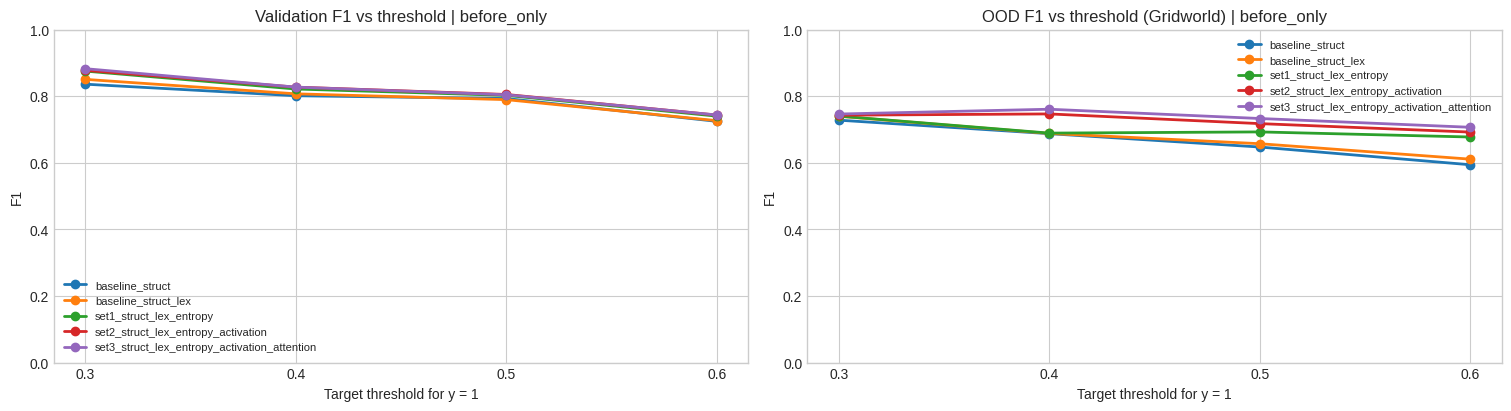

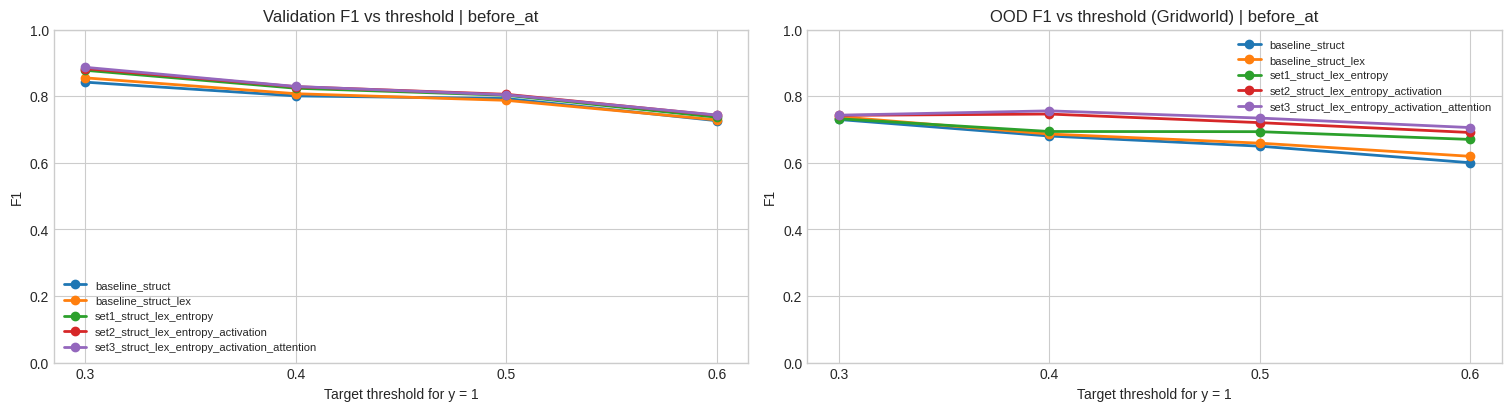

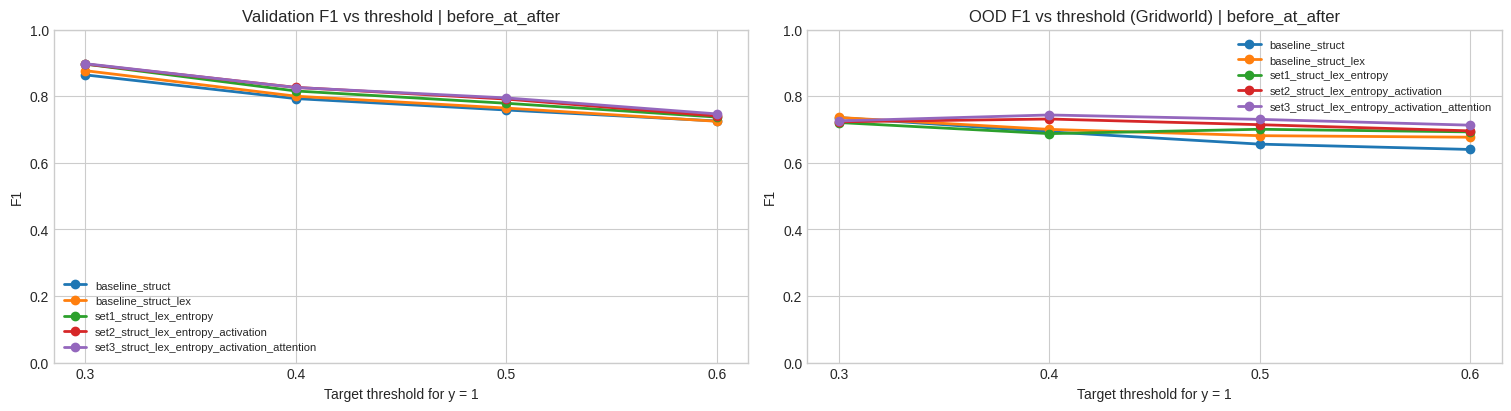

In [15]:
# -------------------------
# F1 vs threshold plots (temporal-scope separated)
# -------------------------
f1_df = classification_df.copy()

split = f1_df['feature_set'].astype(str).str.rsplit('__', n=1, expand=True)
if split.shape[1] == 2:
    f1_df['base_feature_set'] = split[0]
    f1_df['temporal_scope'] = split[1]
else:
    f1_df['base_feature_set'] = f1_df['feature_set']
    f1_df['temporal_scope'] = 'original'

scope_order_pref = ['before_only', 'before_at', 'before_at_after', 'original']
scope_order = [s for s in scope_order_pref if s in set(f1_df['temporal_scope'])]
if len(scope_order) == 0:
    scope_order = sorted(f1_df['temporal_scope'].dropna().unique().tolist())

for scope in scope_order:
    sub_scope = f1_df[f1_df['temporal_scope'] == scope].copy()
    if sub_scope.empty:
        continue

    ordered_sets = [s for s in feature_sets.keys() if s.endswith(f'__{scope}')]
    base_order = [s.rsplit('__', 1)[0] for s in ordered_sets]
    if len(base_order) == 0:
        base_order = sorted(sub_scope['base_feature_set'].unique().tolist())

    val_pivot = sub_scope.pivot_table(
        index='threshold',
        columns='base_feature_set',
        values='val_f1',
        aggfunc='first',
    ).sort_index()
    ood_pivot = sub_scope.pivot_table(
        index='threshold',
        columns='base_feature_set',
        values='ood_f1',
        aggfunc='first',
    ).sort_index()

    fig, axes = plt.subplots(1, 2, figsize=(15, 4), constrained_layout=True)

    for base in base_order:
        if base in val_pivot.columns:
            axes[0].plot(val_pivot.index, val_pivot[base], marker='o', linewidth=2, label=base)
        if base in ood_pivot.columns:
            axes[1].plot(ood_pivot.index, ood_pivot[base], marker='o', linewidth=2, label=base)

    axes[0].set_title(f'Validation F1 vs threshold | {scope}')
    axes[1].set_title(f'OOD F1 vs threshold ({OOD_ENV}) | {scope}')

    for ax in axes:
        ax.set_xlabel('Target threshold for y = 1')
        ax.set_ylabel('F1')
        ax.set_ylim(0.0, 1.0)
        ax.set_xticks(CLASS_THRESHOLDS)
        ax.legend(loc='best', fontsize=8)

    plt.show()


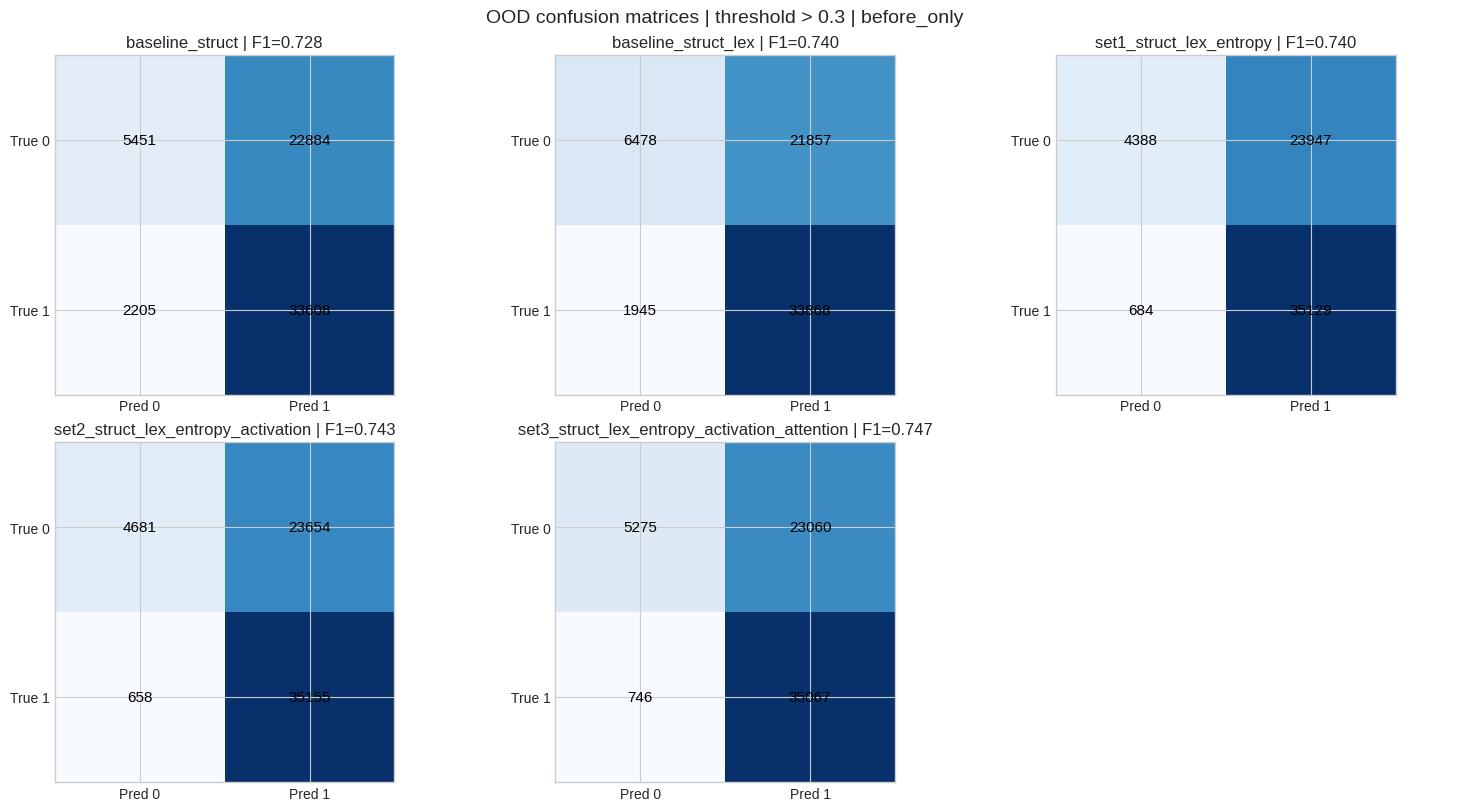

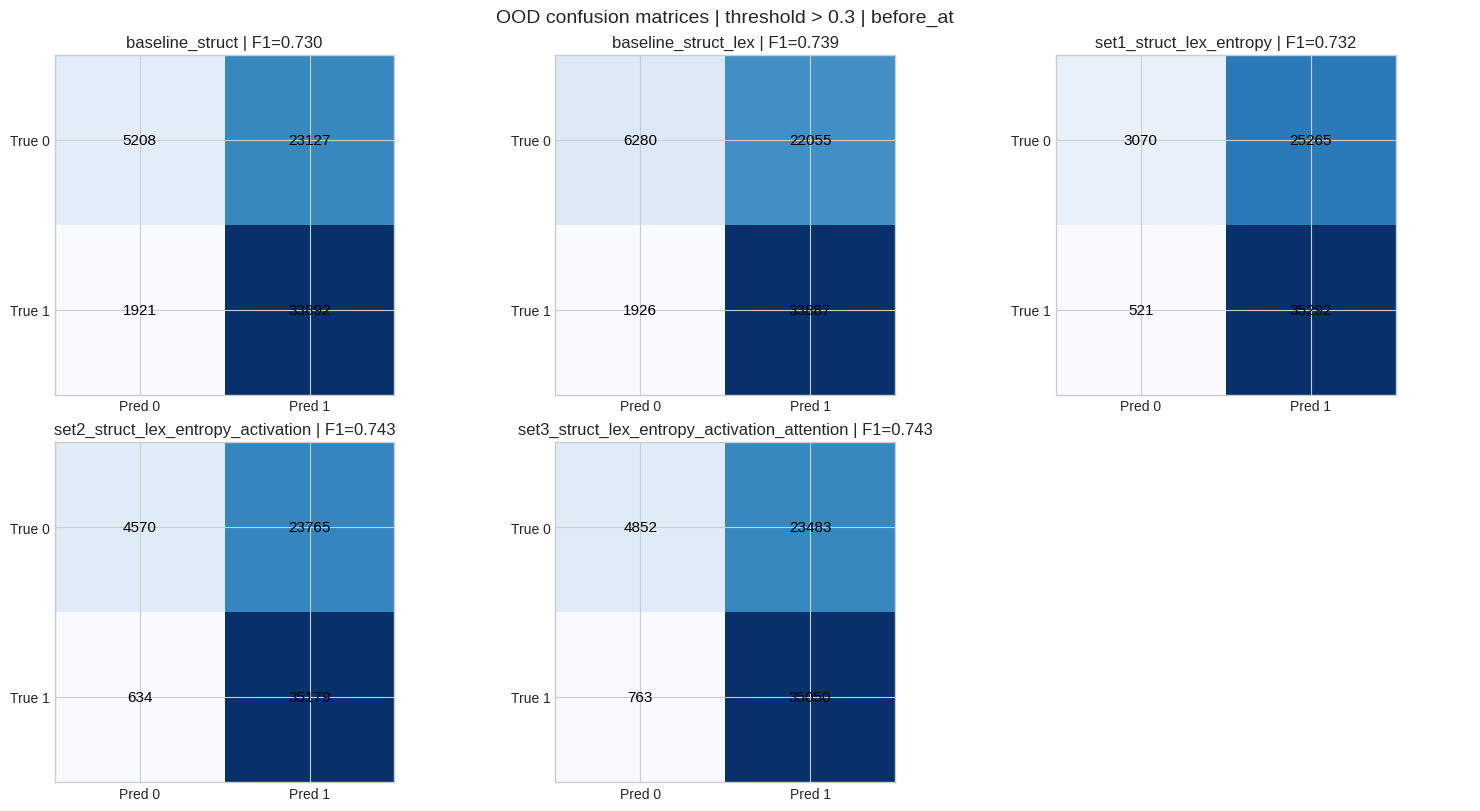

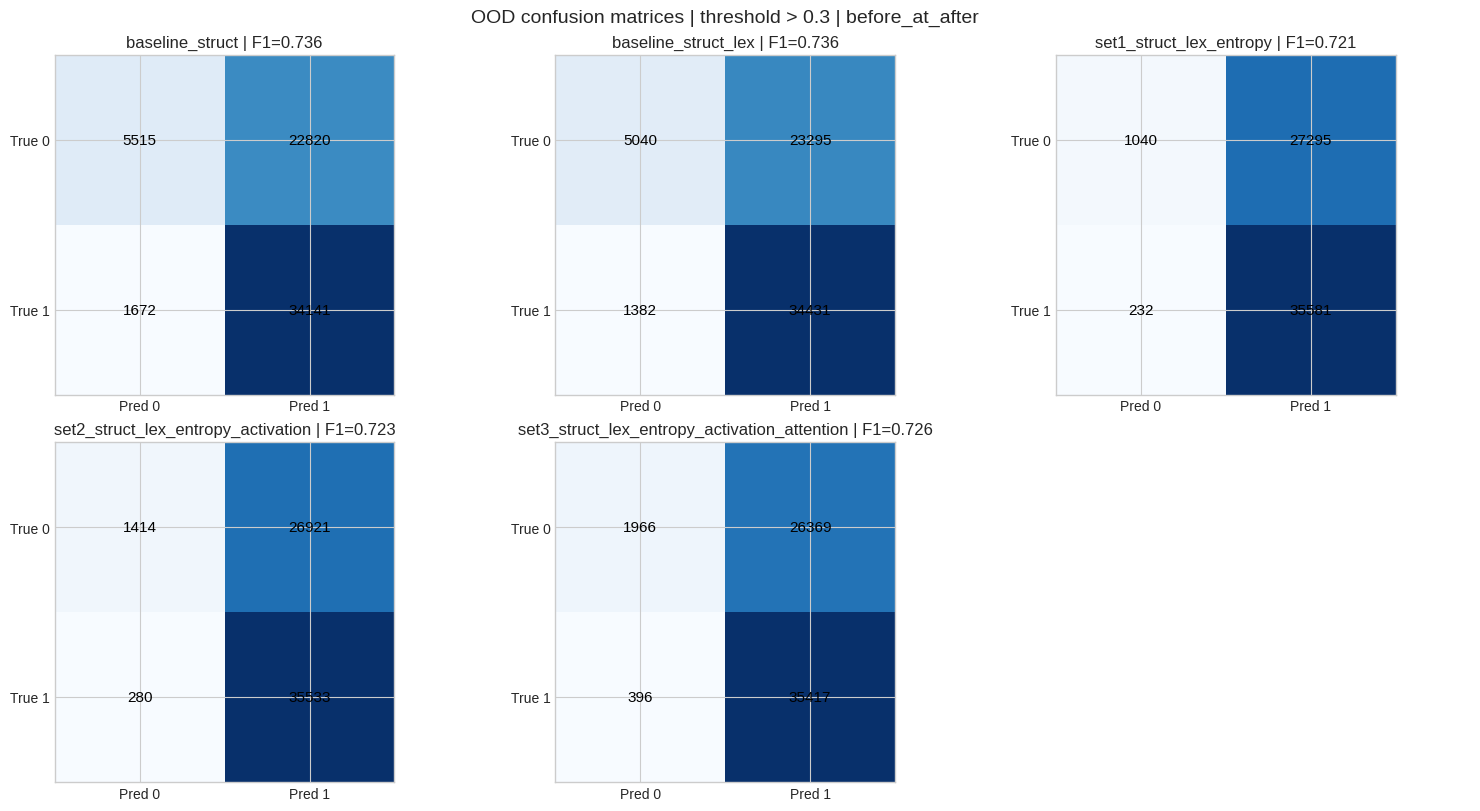

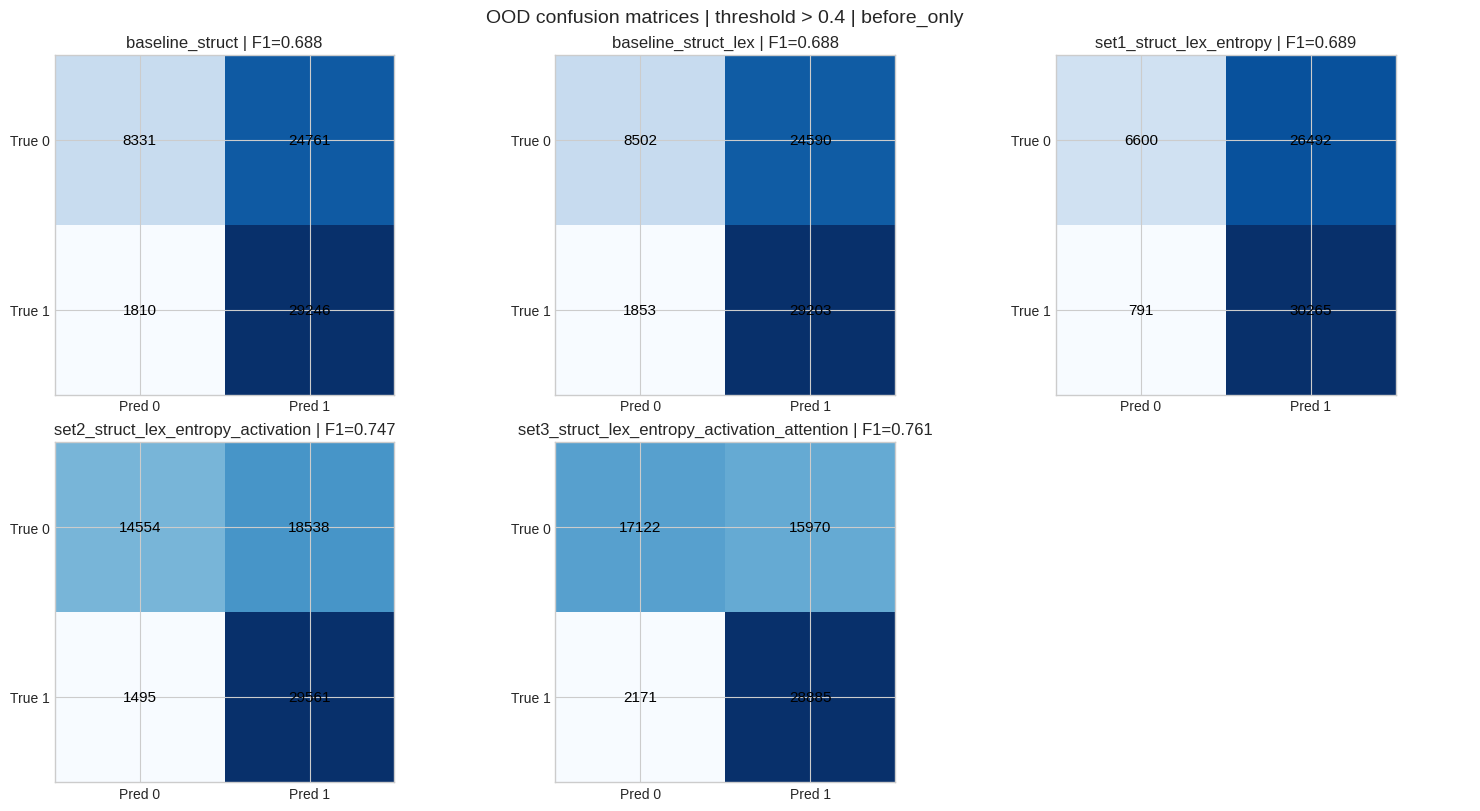

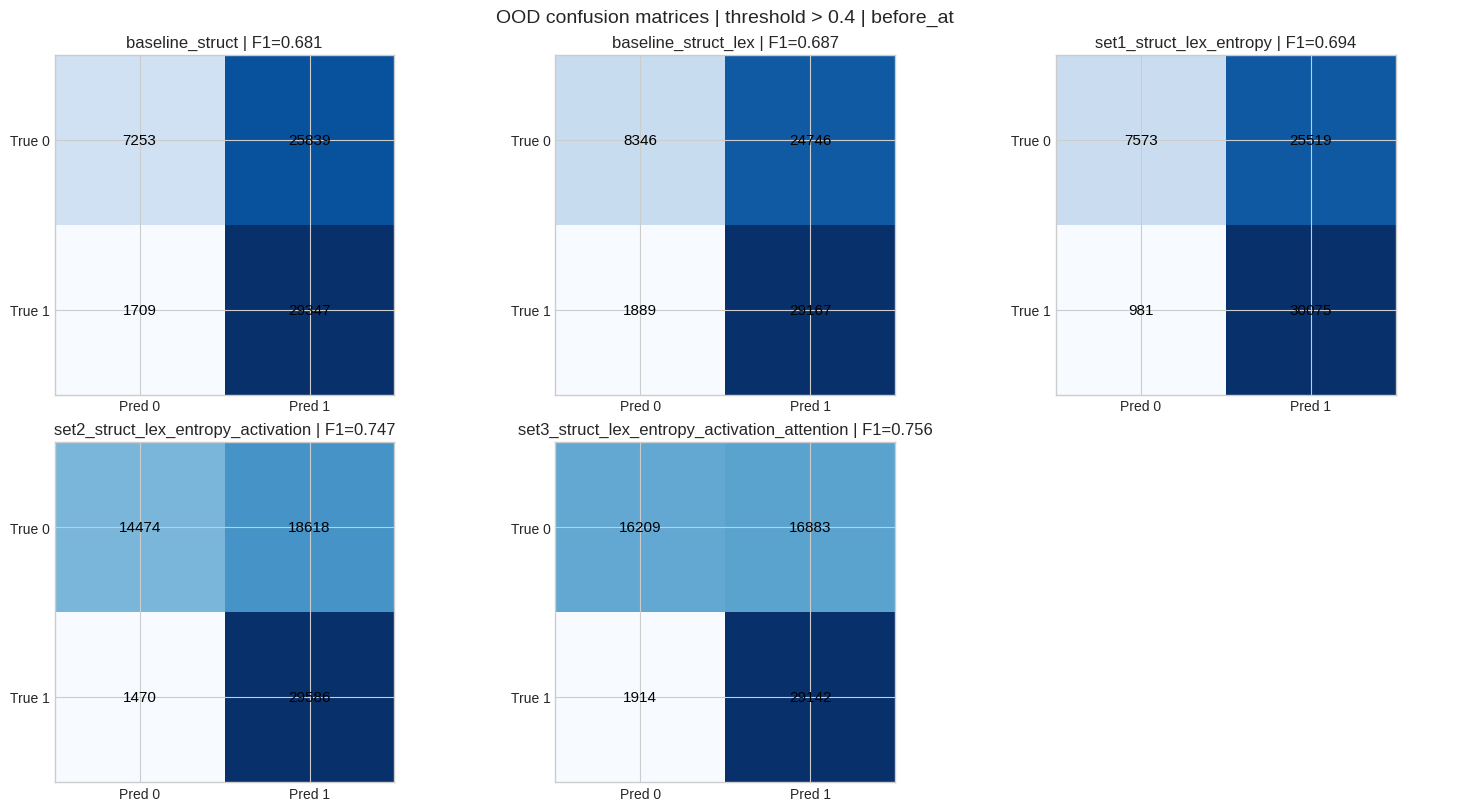

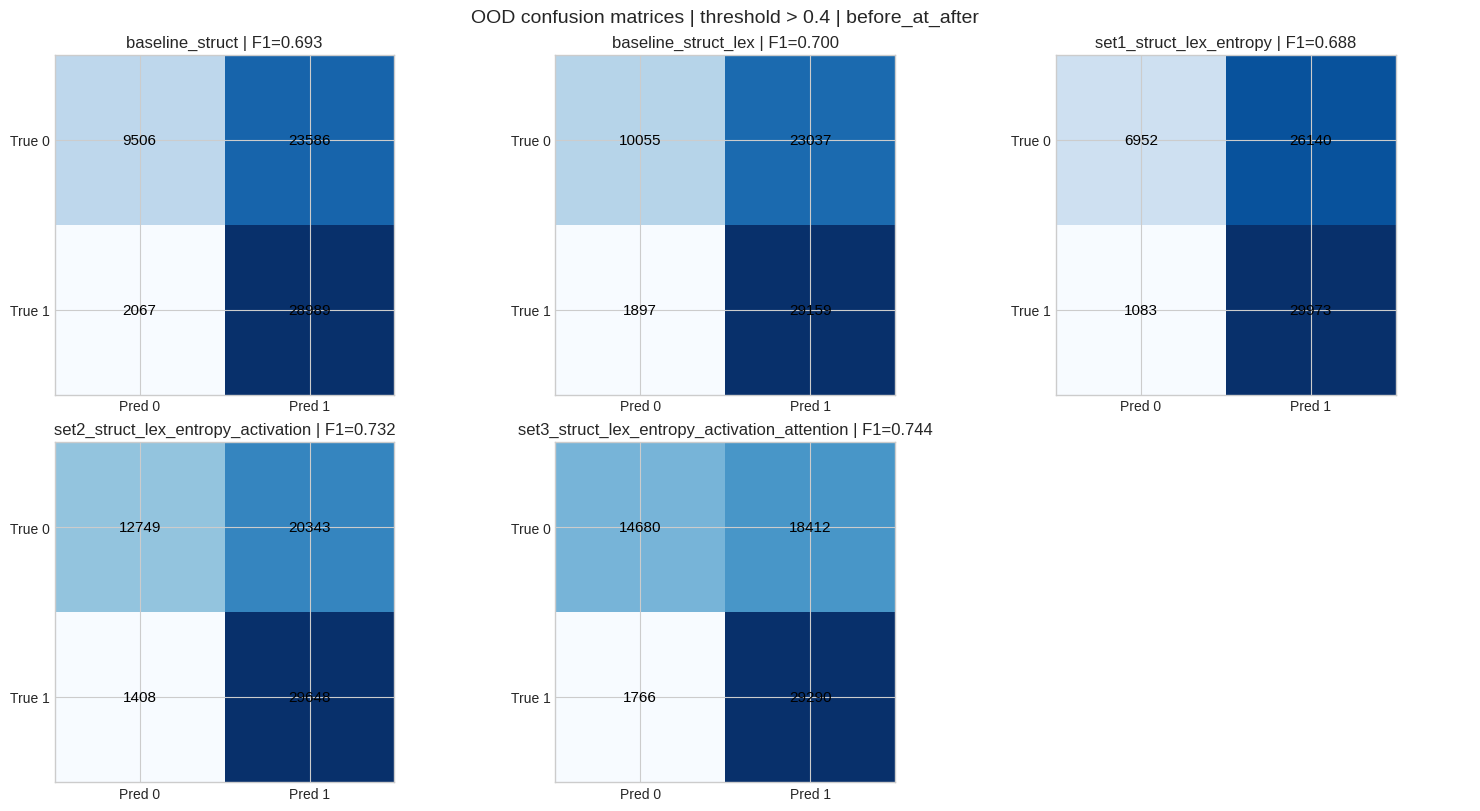

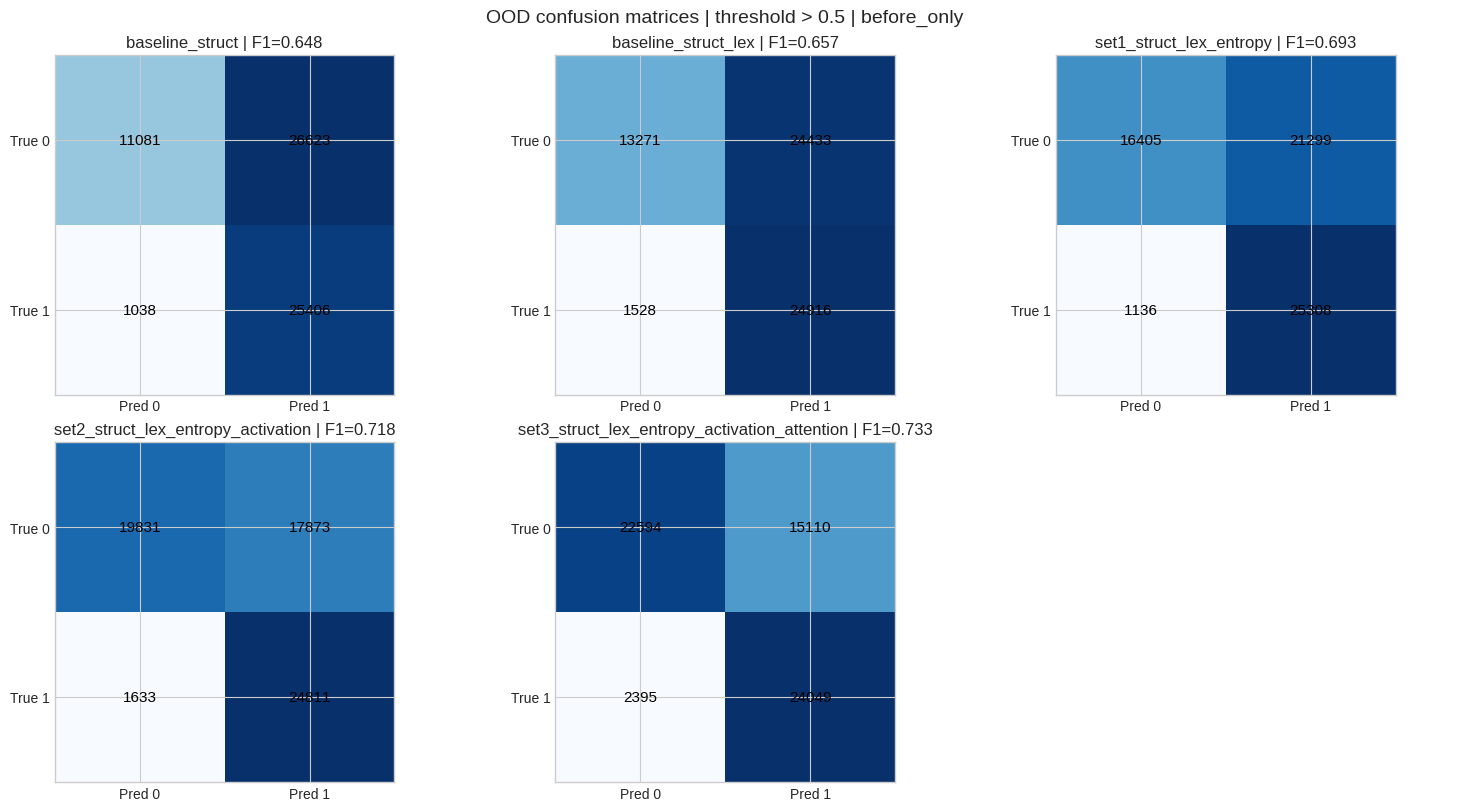

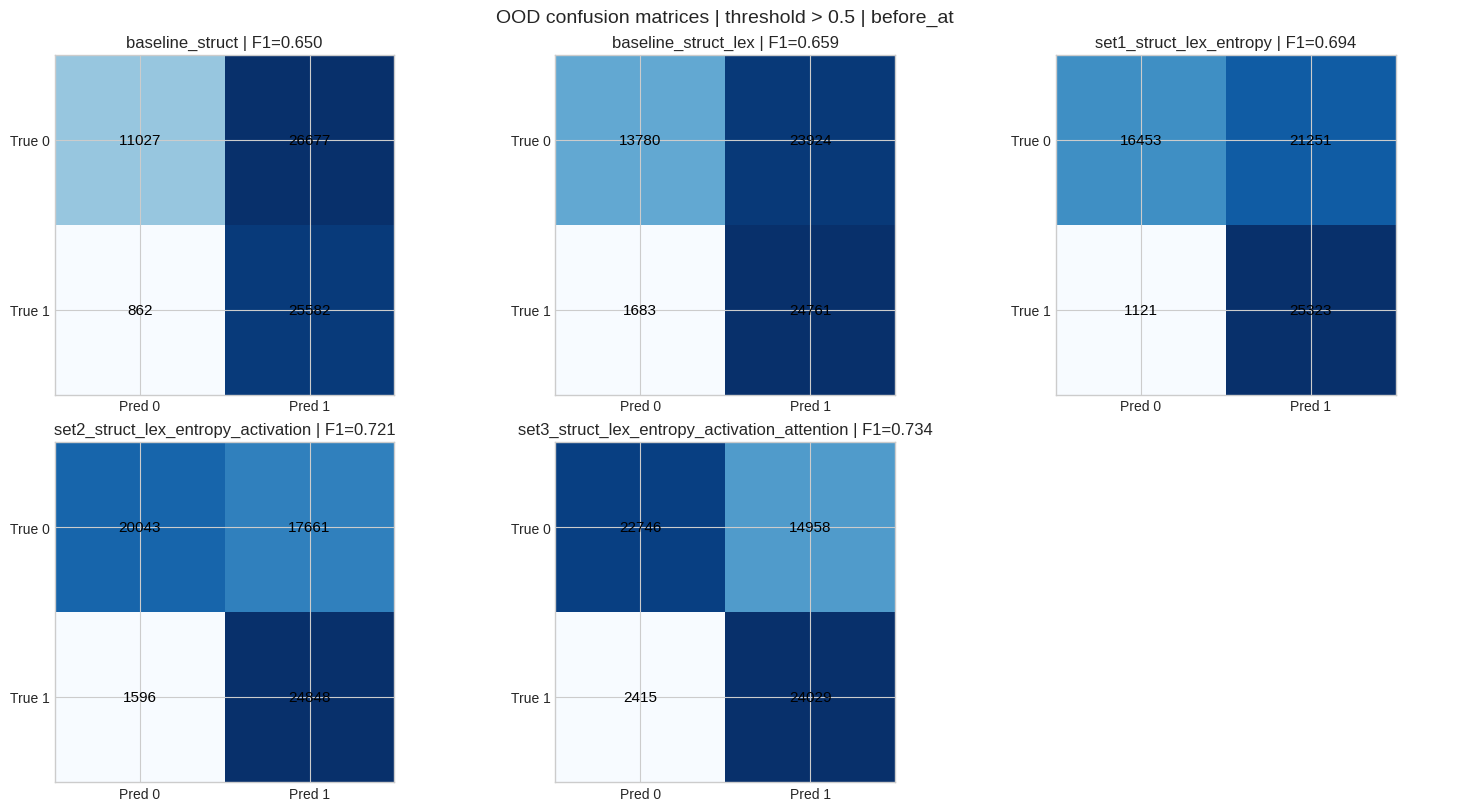

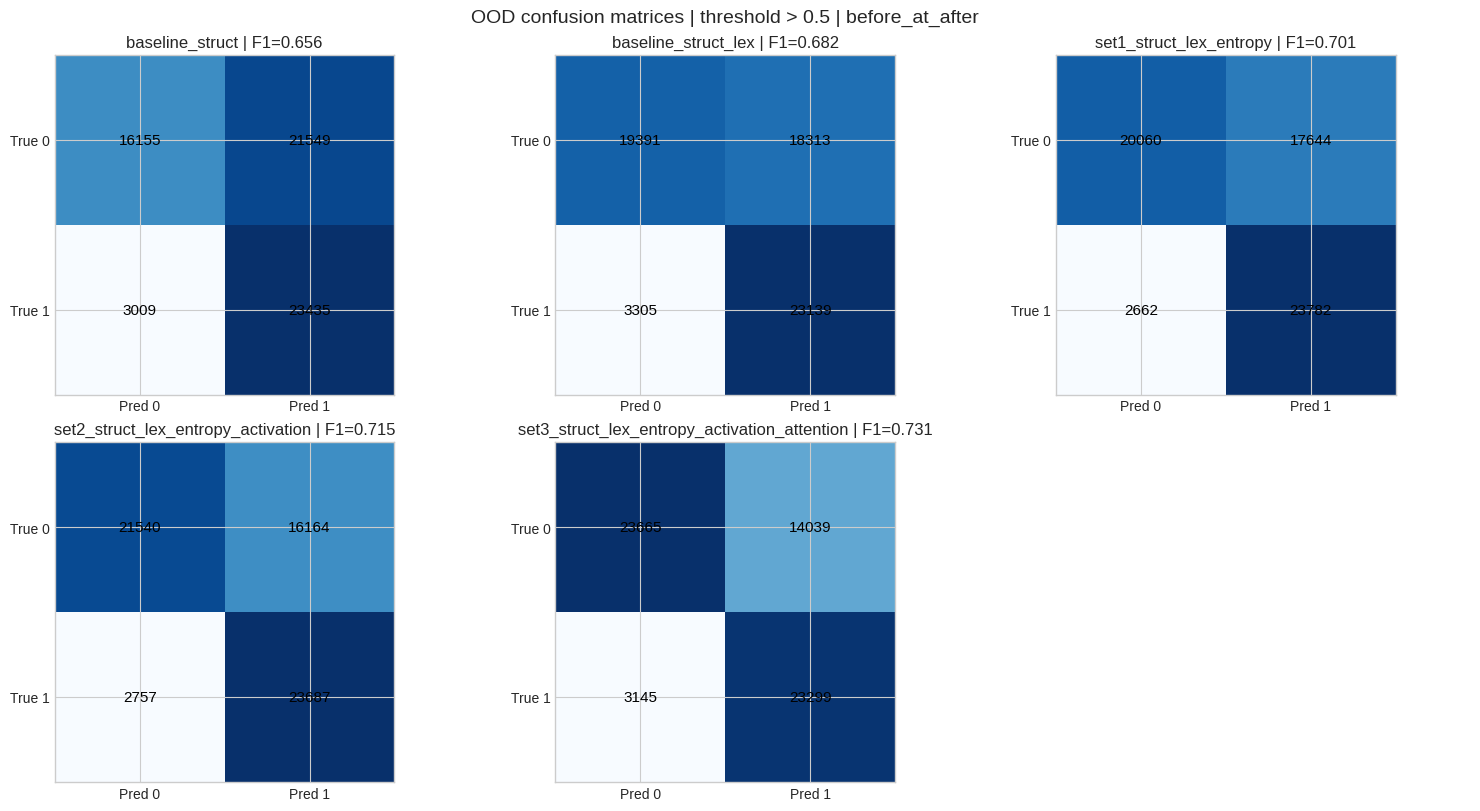

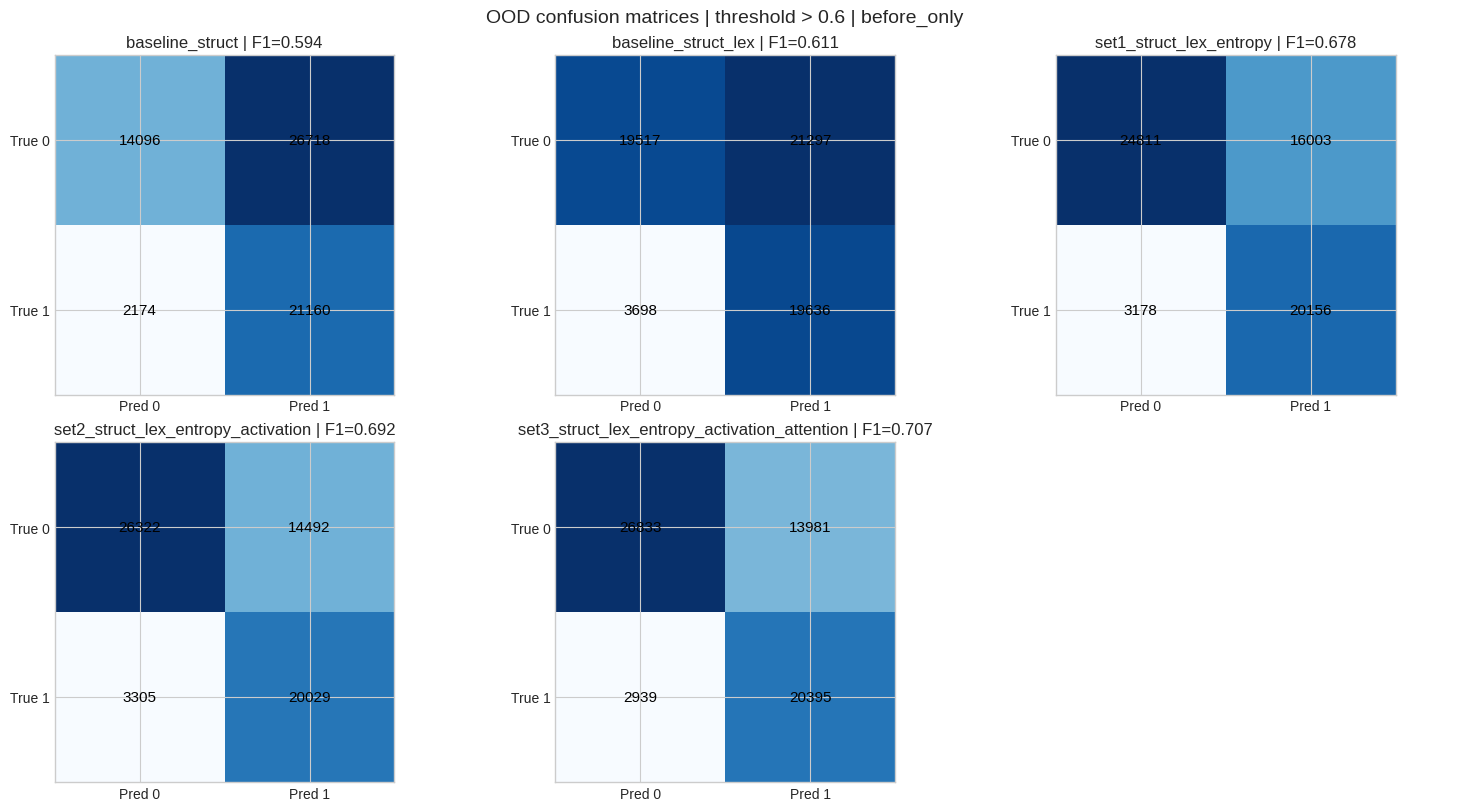

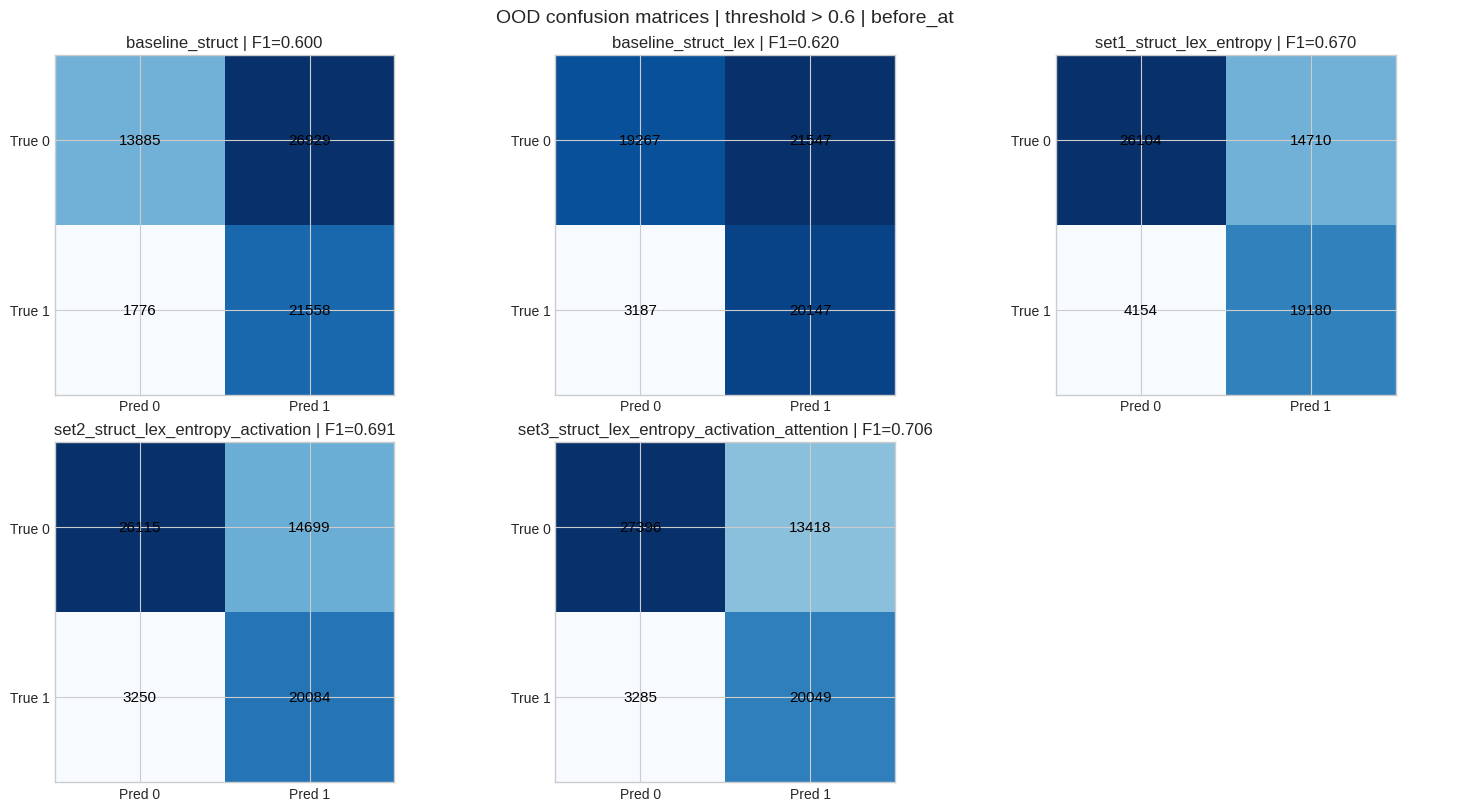

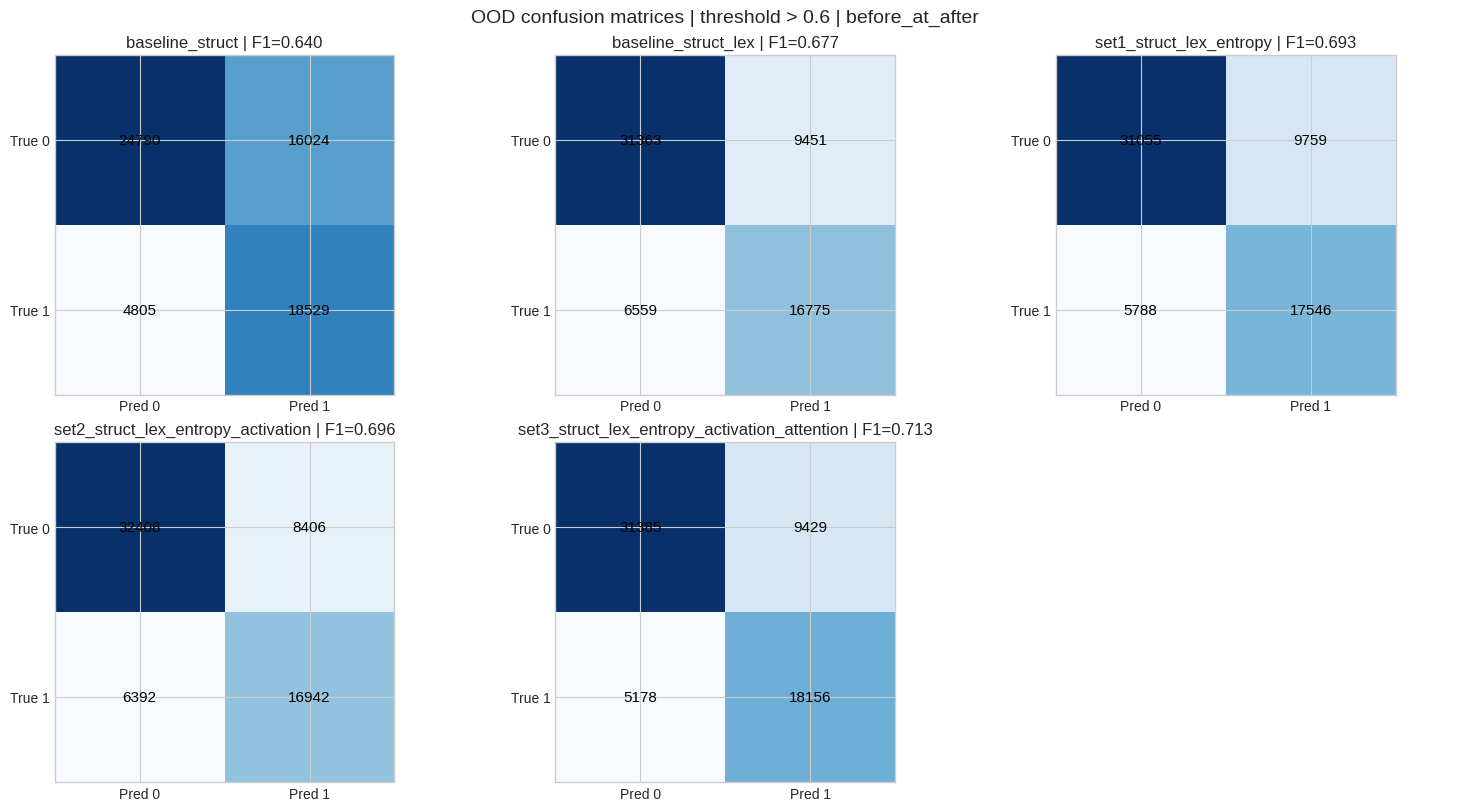

In [16]:
# -------------------------
# Confusion matrices (OOD) by threshold and temporal scope
# -------------------------
def split_feature_set_name(feature_set: str) -> tuple[str, str]:
    txt = str(feature_set)
    parts = txt.rsplit('__', 1)
    if len(parts) == 2 and parts[1] in {'before_only', 'before_at', 'before_at_after'}:
        return parts[0], parts[1]
    return txt, 'original'


def plot_confusion_grid_for_threshold(threshold: float, split: str = 'ood', temporal_scope: str | None = None):
    all_set_names = list(feature_sets.keys())

    if temporal_scope is None:
        set_names = all_set_names
    else:
        set_names = [s for s in all_set_names if split_feature_set_name(s)[1] == temporal_scope]

    if len(set_names) == 0:
        print(f'No feature sets found for scope={temporal_scope}.')
        return

    n = len(set_names)
    ncols = 3
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(5.0 * ncols, 4.0 * nrows), constrained_layout=True)
    axes = np.atleast_1d(axes).reshape(nrows, ncols)

    score_col = 'ood_f1' if split == 'ood' else 'val_f1'

    for idx, set_name in enumerate(set_names):
        r = idx // ncols
        c = idx % ncols
        ax = axes[r, c]

        cm = classification_confmats.get((threshold, set_name, split))
        if cm is None:
            cm = np.array([[0, 0], [0, 0]], dtype=int)

        ax.imshow(cm, cmap='Blues')
        for i in range(2):
            for j in range(2):
                ax.text(j, i, str(int(cm[i, j])), ha='center', va='center', color='black', fontsize=11)

        row = classification_df[(classification_df['threshold'] == threshold) & (classification_df['feature_set'] == set_name)]
        f1_txt = 'nan' if len(row) == 0 else f"{float(row[score_col].iloc[0]):.3f}"
        base_name, _ = split_feature_set_name(set_name)

        ax.set_title(f'{base_name} | F1={f1_txt}')
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(['Pred 0', 'Pred 1'])
        ax.set_yticklabels(['True 0', 'True 1'])

    for idx in range(n, nrows * ncols):
        r = idx // ncols
        c = idx % ncols
        axes[r, c].axis('off')

    split_name = 'OOD' if split == 'ood' else 'Validation'
    scope_txt = temporal_scope if temporal_scope is not None else 'all_scopes'
    fig.suptitle(f'{split_name} confusion matrices | threshold > {threshold:.1f} | {scope_txt}', fontsize=14)
    plt.show()


present_scopes = []
for s in ['before_only', 'before_at', 'before_at_after', 'original']:
    if any(split_feature_set_name(name)[1] == s for name in feature_sets.keys()):
        present_scopes.append(s)

for thr in CLASS_THRESHOLDS:
    for scope in present_scopes:
        plot_confusion_grid_for_threshold(thr, split='ood', temporal_scope=scope)


,threshold,feature_set,feature,gain,weight,cover,val_f1,ood_f1,val_roc_auc,ood_roc_auc
0,0.3,baseline_struct__before_at,before_punct_qmark_mean_std,4.107769,167.0,341.964935,0.842331,0.730179,0.66289,0.630299
1,0.3,baseline_struct__before_at,before_punct_qmark_min_std,3.885195,30.0,284.070984,0.842331,0.730179,0.66289,0.630299
2,0.3,baseline_struct__before_at,before_punct_exclaim_max_std,3.633077,4.0,436.760193,0.842331,0.730179,0.66289,0.630299
3,0.3,baseline_struct__before_at,before_punct_qmark_max_std,3.496368,62.0,269.654663,0.842331,0.730179,0.66289,0.630299
4,0.3,baseline_struct__before_at,before_avg_word_len_min_min,2.946825,488.0,453.805969,0.842331,0.730179,0.66289,0.630299
5,0.3,baseline_struct__before_at,before_avg_word_len_max_min,2.847303,1230.0,458.498413,0.842331,0.730179,0.66289,0.630299
6,0.3,baseline_struct__before_at,before_avg_word_len_mean_min,2.623581,3090.0,442.964508,0.842331,0.730179,0.66289,0.630299
7,0.3,baseline_struct__before_at,before_punct_exclaim_mean_mean,2.299279,8.0,804.654663,0.842331,0.730179,0.66289,0.630299
8,0.3,baseline_struct__before_at,before_negation_count_max_max,2.120059,12.0,447.674042,0.842331,0.730179,0.66289,0.630299
9,0.3,baseline_struct__before_at,before_negation_count_min_mean,2.051254,12.0,379.319366,0.842331,0.730179,0.66289,0.630299


Saved: /playpen-ssd/smerrill/deception2/BS/Results/SentencePipeline/v1/ood_modeling/BS_to_Gridworld__temporal_reduced__scope_sweep__xgb_classification_importance.csv


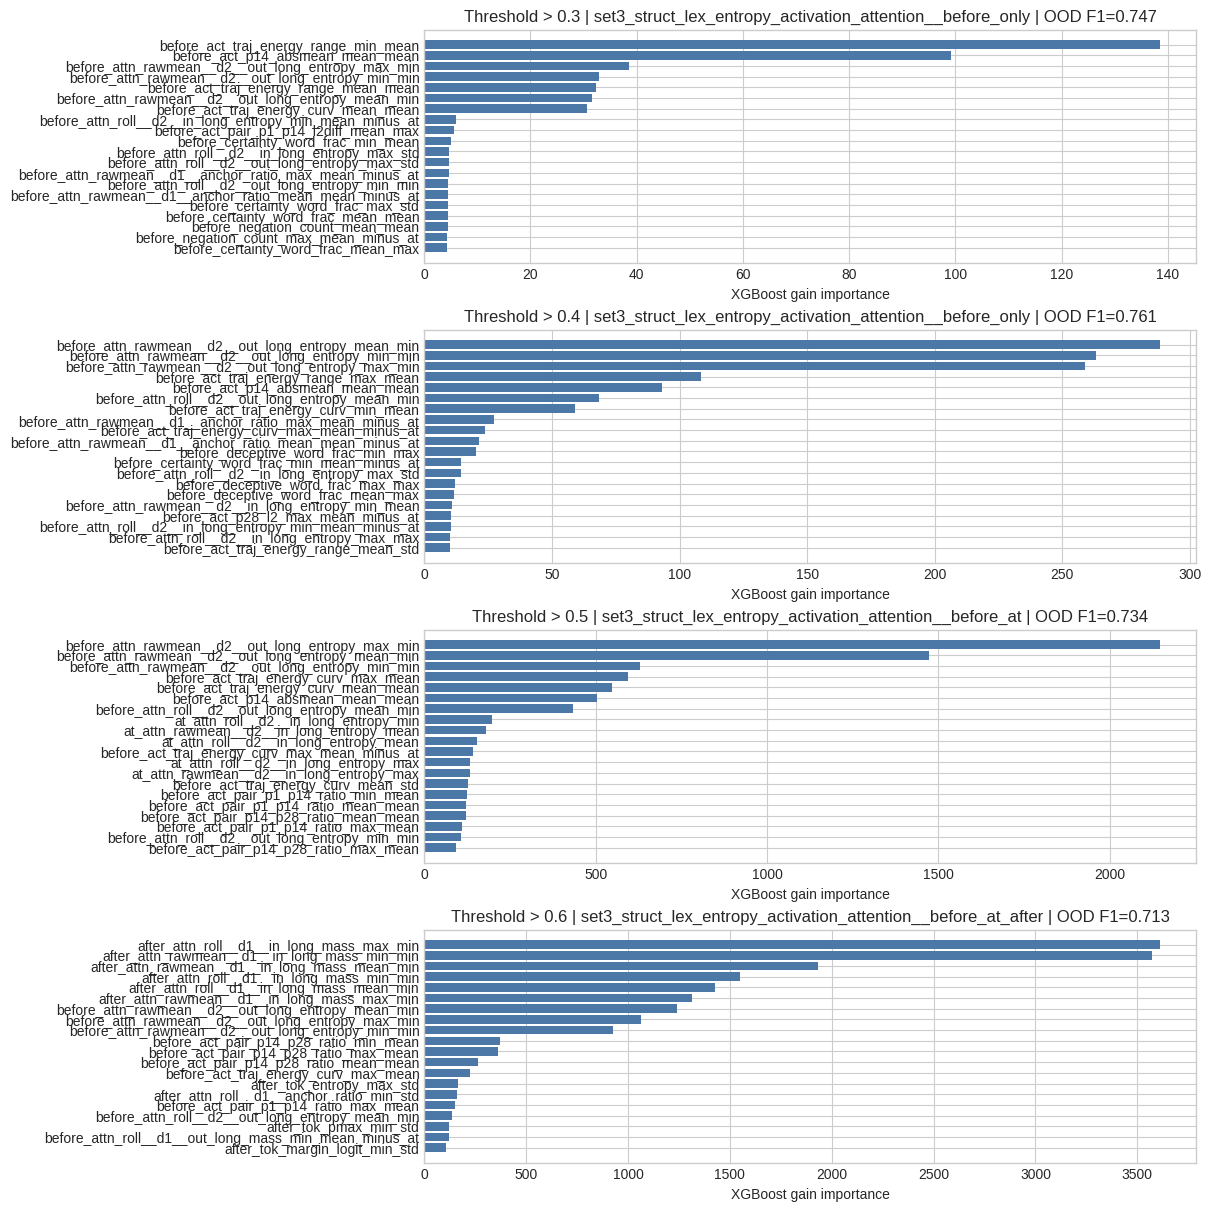

In [28]:
# Binary classifier feature importances (no re-training)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

if "classification_models" not in globals() or not classification_models:
    raise RuntimeError("classification_models is missing/empty. Run the classifier training cell first.")
if "classification_df" not in globals():
    raise RuntimeError("classification_df is missing. Run the classifier training cell first.")

def _decode_xgb_feature_name(raw_name: str, model) -> str:
    # XGBoost can emit f0/f1/...; map back to real column names when available.
    if (
        isinstance(raw_name, str)
        and raw_name.startswith("f")
        and raw_name[1:].isdigit()
        and hasattr(model, "feature_names_in_")
    ):
        idx = int(raw_name[1:])
        names = list(model.feature_names_in_)
        if 0 <= idx < len(names):
            return names[idx]
    return str(raw_name)

rows = []
for (thr, set_name), model in classification_models.items():
    booster = model.get_booster()
    gain = booster.get_score(importance_type="gain")
    weight = booster.get_score(importance_type="weight")
    cover = booster.get_score(importance_type="cover")

    all_keys = set(gain) | set(weight) | set(cover)
    for k in all_keys:
        rows.append(
            {
                "threshold": float(thr),
                "feature_set": str(set_name),
                "feature": _decode_xgb_feature_name(k, model),
                "gain": float(gain.get(k, 0.0)),
                "weight": float(weight.get(k, 0.0)),
                "cover": float(cover.get(k, 0.0)),
            }
        )

classification_importance_df = pd.DataFrame(rows)
if classification_importance_df.empty:
    raise RuntimeError("No feature importances found in classification_models.")

score_cols = ["threshold", "feature_set", "val_f1", "ood_f1", "val_roc_auc", "ood_roc_auc"]
score_cols = [c for c in score_cols if c in classification_df.columns]
score_df = classification_df[score_cols].drop_duplicates()

classification_importance_df = classification_importance_df.merge(
    score_df, on=["threshold", "feature_set"], how="left"
).sort_values(
    ["threshold", "feature_set", "gain"], ascending=[True, True, False]
).reset_index(drop=True)

display(classification_importance_df.head(30))

# Save full table
if "run_tag" in globals() and "RESULTS_DIR" in globals():
    imp_out = RESULTS_DIR / f"{run_tag}__xgb_classification_importance.csv"
else:
    imp_out = Path("xgb_classification_importance.csv")
classification_importance_df.to_csv(imp_out, index=False)
print(f"Saved: {imp_out}")

# Plot top gain features for best available model at each threshold (by OOD F1)
model_keys_df = pd.DataFrame(
    [{"threshold": float(k[0]), "feature_set": str(k[1])} for k in classification_models.keys()]
)
eligible = classification_df.merge(model_keys_df, on=["threshold", "feature_set"], how="inner")
best_by_thr = (
    eligible.sort_values(["threshold", "ood_f1"], ascending=[True, False])
    .drop_duplicates(["threshold"])
    .sort_values("threshold")
)

top_n = 20
n = len(best_by_thr)
fig, axes = plt.subplots(n, 1, figsize=(12, max(3, 3 * n)), constrained_layout=True)
if n == 1:
    axes = [axes]

for ax, (_, r) in zip(axes, best_by_thr.iterrows()):
    thr = float(r["threshold"])
    fs = str(r["feature_set"])
    sub = classification_importance_df[
        (classification_importance_df["threshold"] == thr)
        & (classification_importance_df["feature_set"] == fs)
    ].sort_values("gain", ascending=False).head(top_n)

    ax.barh(sub["feature"].iloc[::-1], sub["gain"].iloc[::-1], color="#4c78a8")
    ax.set_xlabel("XGBoost gain importance")
    ax.set_title(f"Threshold > {thr:.1f} | {fs} | OOD F1={float(r['ood_f1']):.3f}")

plt.show()

# Optional helper for any specific classifier
def plot_cls_importance(threshold, feature_set, metric="gain", top_n=25):
    sub = classification_importance_df[
        (classification_importance_df["threshold"] == float(threshold))
        & (classification_importance_df["feature_set"] == str(feature_set))
    ].sort_values(metric, ascending=False).head(top_n)

    if sub.empty:
        print(f"No importance rows for threshold={threshold}, feature_set={feature_set}")
        return

    plt.figure(figsize=(10, max(4, 0.3 * len(sub))))
    plt.barh(sub["feature"].iloc[::-1], sub[metric].iloc[::-1], color="#f58518")
    plt.xlabel(f"XGBoost {metric} importance")
    plt.title(f"{feature_set} | threshold>{float(threshold):.1f}")
    plt.tight_layout()
    plt.show()


## Notes

- Default direction is `BS -> Gridworld` (`TRAIN_ENV = 'BS'`).
- `FEATURE_SOURCE_MODE = 'temporal_reduced'` auto-resolves the latest valid temporal artifact pair in each env directory.
- Temporal artifacts are searched in this order: `features.parque + features_feature_sets.json`, then `features.parquet + features_feature_sets.json`, then `features_temporal_reduced.parquet + features_temporal_reduced_feature_sets.json`.
- Set `FEATURE_SOURCE_MODE = 'raw'` to use legacy wide feature tables and notebook-defined feature sets.
- To run reverse OOD, set `TRAIN_ENV = 'Gridworld'` and rerun all cells.
- Regression metrics are selected by validation RMSE and reported on both validation and OOD test.
- Classification metrics are saved to `...__xgb_classification_metrics.csv` and include F1/precision/recall/accuracy/ROC-AUC for each threshold and feature set.
- `ENABLE_TEMPORAL_SCOPE_SWEEP = True` expands each base set into `__before_only`, `__before_at`, and `__before_at_after` variants.
- Temporal-scope sweeps now render scope-separated RMSE, F1-vs-threshold, and confusion-matrix figures for `before_only`, `before_at`, and `before_at_after`.
